Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary of Navi Mumbai...
Saved outer boundary to output/navi_mumbai_boundary.geojson
Saved streets to output/navi_mumbai_streets.geojson
Sampling 200 random points on streets...
Saved sampled points to output/navi_mumbai_sampled_points.geojson
Creating visualization...
Saved visualization to output/navi_mumbai_visualization.png

Process completed successfully!


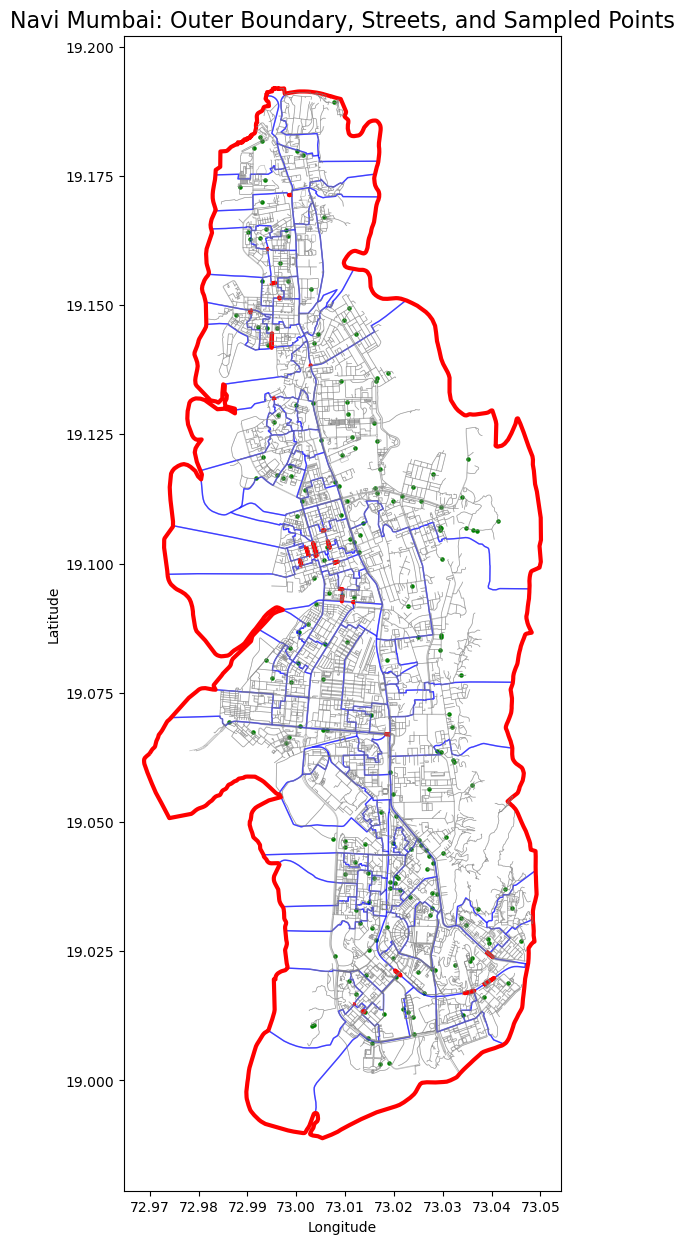

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from shapely.geometry import Point, Polygon, LineString, MultiPolygon
from shapely.ops import unary_union
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
import osmnx as ox

def extract_wards_from_kml(kml_content):
    """
    Extract ward boundaries from KML content and convert them to GeoDataFrame
    
    Parameters:
    -----------
    kml_content : str
        Content of the KML file
        
    Returns:
    --------
    gdf : GeoDataFrame
        GeoDataFrame containing the ward boundaries
    """
    # Parse the KML content
    soup = BeautifulSoup(kml_content, 'xml')
    
    # Find all Placemarks
    placemarks = soup.find_all('Placemark')
    
    # Prepare data for GeoDataFrame
    geometries = []
    properties = []
    
    for placemark in placemarks:
        # Extract data from the placemark
        simple_data = placemark.find_all('SimpleData')
        
        # Create a dictionary for the properties
        prop = {}
        for data in simple_data:
            prop[data['name']] = data.text
        
        # Extract coordinates
        coordinates_elem = placemark.find('coordinates')
        if coordinates_elem:
            coordinates_text = coordinates_elem.text.strip()
            
            # Parse coordinates (format is: lon,lat,alt lon,lat,alt ...)
            coords_list = []
            for coord in coordinates_text.split():
                parts = coord.split(',')
                # Ensure we have at least lon and lat
                if len(parts) >= 2:
                    lon, lat = float(parts[0]), float(parts[1])
                    coords_list.append((lon, lat))
            
            # Create polygon geometry
            if len(coords_list) >= 3:  # Need at least 3 points for a polygon
                poly = Polygon(coords_list)
                geometries.append(poly)
                properties.append(prop)
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    return gdf

def extract_outer_boundary(wards_gdf):
    """
    Extract the outer boundary of all wards
    
    Parameters:
    -----------
    wards_gdf : GeoDataFrame
        GeoDataFrame containing ward boundaries
        
    Returns:
    --------
    boundary : Polygon or MultiPolygon
        The outer boundary of all wards
    """
    # Combine all ward geometries
    combined = unary_union(wards_gdf.geometry.tolist())
    
    # If it's a MultiPolygon, get the largest polygon as the main boundary
    if isinstance(combined, MultiPolygon):
        # Find the polygon with the largest area
        largest_poly = max(combined.geoms, key=lambda x: x.area)
        return largest_poly
    
    return combined

def get_streets_from_osm(boundary):
    """
    Download street network from OpenStreetMap within the boundary
    
    Parameters:
    -----------
    boundary : Polygon or MultiPolygon
        The boundary to download streets for
        
    Returns:
    --------
    edges : GeoDataFrame
        GeoDataFrame containing street edges
    """
    print("Downloading street network from OpenStreetMap...")
    G = ox.graph_from_polygon(boundary, network_type='all')
    
    # Convert to GeoDataFrame
    nodes, edges = ox.graph_to_gdfs(G)
    
    return edges

def sample_points_on_streets(edges, boundary, n_points=100):
    """
    Sample random points along streets within the boundary
    
    Parameters:
    -----------
    edges : GeoDataFrame
        GeoDataFrame containing street edges
    boundary : Polygon or MultiPolygon
        The boundary to sample points within
    n_points : int
        Number of random points to sample
    
    Returns:
    --------
    sampled_points : GeoDataFrame
        GeoDataFrame containing the sampled points
    """
    # Calculate lengths if not already available
    if 'length' not in edges.columns:
        edges['length'] = edges.geometry.length
    
    # Filter edges to only those within the boundary
    edges['within'] = edges.geometry.apply(lambda geom: geom.within(boundary) or geom.intersects(boundary))
    edges_within = edges[edges['within']]
    
    # Normalize lengths to create probability weights
    total_length = edges_within['length'].sum()
    edges_within['prob'] = edges_within['length'] / total_length
    
    # Handle case where all edges are too small compared to boundary
    if len(edges_within) == 0:
        print("Warning: No edges found within boundary. Using all edges.")
        edges_within = edges
        total_length = edges['length'].sum()
        edges_within['prob'] = edges_within['length'] / total_length
    
    # Randomly select edges based on their length
    selected_indices = np.random.choice(
        edges_within.index,
        size=n_points,
        replace=True,
        p=edges_within['prob'].values
    )
    
    # For each selected edge, sample a random point along it
    points = []
    for idx in selected_indices:
        edge = edges_within.loc[idx]
        line = edge.geometry
        random_position = random.random()
        point = line.interpolate(random_position, normalized=True)
        
        # Store the point with attributes
        points.append({
            'geometry': point,
            'street_name': edge.get('name', 'Unnamed'),
            'highway_type': edge.get('highway', 'Unknown'),
            'length': edge.get('length', None)
        })
    
    # Create a GeoDataFrame from the points
    sampled_points = gpd.GeoDataFrame(points, crs=edges.crs)
    
    return sampled_points

def main(kml_content, output_dir="output", n_points=200):
    """
    Main function to process KML content, extract outer boundary,
    download streets from OSM, and sample random points
    
    Parameters:
    -----------
    kml_content : str
        Content of the KML file
    output_dir : str
        Directory to save the output files
    n_points : int
        Number of random points to sample
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Extract wards from KML
    print("Extracting ward boundaries from KML...")
    wards_gdf = extract_wards_from_kml(kml_content)
    
    # Print summary of the wards
    print(f"Found {len(wards_gdf)} wards in the KML file")
    
    # Check if we have any wards
    if len(wards_gdf) == 0:
        print("No ward boundaries found in the KML file")
        return
    
    # Extract outer boundary
    print("Extracting outer boundary of Navi Mumbai...")
    outer_boundary = extract_outer_boundary(wards_gdf)
    
    # Create a GeoDataFrame for the outer boundary
    boundary_gdf = gpd.GeoDataFrame([{'name': 'Navi Mumbai'}], geometry=[outer_boundary], crs="EPSG:4326")
    
    # Save outer boundary as GeoJSON
    boundary_geojson_path = os.path.join(output_dir, "navi_mumbai_boundary.geojson")
    boundary_gdf.to_file(boundary_geojson_path, driver="GeoJSON")
    print(f"Saved outer boundary to {boundary_geojson_path}")
    
    # Get streets from OSM
    edges = get_streets_from_osm(outer_boundary)
    
    # Save streets as GeoJSON
    streets_geojson_path = os.path.join(output_dir, "navi_mumbai_streets.geojson")
    edges.to_file(streets_geojson_path, driver="GeoJSON")
    print(f"Saved streets to {streets_geojson_path}")
    
    # Sample random points on streets
    print(f"Sampling {n_points} random points on streets...")
    sampled_points = sample_points_on_streets(edges, outer_boundary, n_points=n_points)
    
    # Save sampled points as GeoJSON
    points_geojson_path = os.path.join(output_dir, "navi_mumbai_sampled_points.geojson")
    sampled_points.to_file(points_geojson_path, driver="GeoJSON")
    print(f"Saved sampled points to {points_geojson_path}")
    
    # Create a visualization
    print("Creating visualization...")
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Plot ward boundaries
    wards_gdf.boundary.plot(ax=ax, linewidth=1, color='blue', alpha=0.5)
    
    # Plot outer boundary
    boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='red')
    
    # Plot streets
    edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.5)
    
    # Plot sampled points
    sampled_points.plot(ax=ax, markersize=5, color='green')
    
    # Add title and labels
    ax.set_title("Navi Mumbai: Outer Boundary, Streets, and Sampled Points", fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Save the figure
    fig_path = os.path.join(output_dir, "navi_mumbai_visualization.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved visualization to {fig_path}")
    
    print("\nProcess completed successfully!")
    return boundary_gdf, edges, sampled_points

# Example usage:
if __name__ == "__main__":
    # Load KML file
    with open('../data/navi_mumbai_wards_map_2024.kml', 'r') as f:
        kml_content = f.read()
    
    # Process KML, extract boundary, and sample points
    boundary_gdf, edges, sampled_points = main(kml_content, n_points=200)

In [19]:
def generate_itineraries(G, sampled_points, n_routes=1):
    """
    Generate itineraries that cover all sampled points using a shortest path approach
    
    Parameters:
    -----------
    G : networkx.MultiDiGraph
        Street network graph
    sampled_points : GeoDataFrame
        GeoDataFrame containing sampled points
    n_routes : int
        Number of separate itineraries to generate (divides points among routes)
        
    Returns:
    --------
    routes_gdf : GeoDataFrame
        GeoDataFrame containing the routes
    """
    import numpy as np
    from shapely.geometry import LineString
    
    # Get all point IDs
    all_point_ids = sampled_points['point_id'].tolist()
    
    # Calculate number of points per route
    points_per_route = max(3, len(all_point_ids) // n_routes)
    
    routes = []
    
    # For each route
    for route_idx in range(n_routes):
        # Get point IDs for this route
        start_idx = route_idx * points_per_route
        end_idx = min((route_idx + 1) * points_per_route, len(all_point_ids))
        
        # If we've used all points, break
        if start_idx >= len(all_point_ids):
            break
            
        route_point_ids = all_point_ids[start_idx:end_idx]
        
        # Need at least 2 points for a route
        if len(route_point_ids) < 2:
            continue
            
        # Get the points for this route
        route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)].copy()
        
        # Solve the "Traveling Salesperson Problem" to find shortest path visiting all points
        # This is a simplified greedy approach: start at first point and always go to nearest unvisited point
        
        # Initialize with first point
        current_point_id = route_point_ids[0]
        remaining_point_ids = set(route_point_ids[1:])
        ordered_point_ids = [current_point_id]
        
        # Find the nearest node for the starting point
        current_node = route_points[route_points['point_id'] == current_point_id].iloc[0]['node_id']
        
        # Store all path segments
        all_path_segments = []
        total_length = 0
        total_travel_time = 0
        
        # Visit each remaining point, always choosing the closest
        while remaining_point_ids:
            # Find the closest point by network distance
            min_distance = float('inf')
            next_point_id = None
            next_path = None
            
            for point_id in remaining_point_ids:
                # Get the node ID for this point
                next_node = route_points[route_points['point_id'] == point_id].iloc[0]['node_id']
                
                try:
                    # Find shortest path to this point
                    path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                    
                    # Calculate path length
                    path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    
                    # If this is the shortest path so far, save it
                    if path_length < min_distance:
                        min_distance = path_length
                        next_point_id = point_id
                        next_path = path
                        next_node = next_node
                        
                except nx.NetworkXNoPath:
                    # If no path found, skip this point
                    print(f"No path found to point {point_id}, skipping...")
                    continue
            
            # If we couldn't find a path to any remaining point, break
            if next_point_id is None:
                print(f"Couldn't find paths to remaining points, ending route early")
                break
                
            # Add this point to our ordered list and remove from remaining
            ordered_point_ids.append(next_point_id)
            remaining_point_ids.remove(next_point_id)
            
            # Update current point and node for next iteration
            current_point_id = next_point_id
            current_node = next_node
            
            # Convert path to geometry and add to segments
            path_geom = []
            path_length = 0
            path_time = 0
            
            for u, v in zip(next_path[:-1], next_path[1:]):
                # Get the edge data
                edge_data = G.get_edge_data(u, v, 0)
                
                # Add to length and time
                path_length += edge_data['length']
                path_time += edge_data['travel_time']
                
                if 'geometry' in edge_data:
                    # If it has a geometry attribute (LineString), use it
                    path_geom.append(edge_data['geometry'])
                else:
                    # Otherwise, create a straight line between the nodes
                    u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                    v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                    path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
            
            # Merge all segments into a single LineString
            if path_geom:
                path_line = LineString([p for line in path_geom for p in line.coords])
                all_path_segments.append(path_line)
                
                # Add to route totals
                total_length += path_length
                total_travel_time += path_time
        
        # Combine all path segments into a single MultiLineString
        if all_path_segments:
            from shapely.geometry import MultiLineString
            route_line = MultiLineString(all_path_segments)
            
            routes.append({
                'geometry': route_line,
                'point_ids': ordered_point_ids,
                'length_m': total_length,
                'travel_time_min': total_travel_time / 60,  # Convert to minutes
                'n_points': len(ordered_point_ids),
                'route_id': route_idx + 1
            })
            
            print(f"Created route {route_idx+1} visiting {len(ordered_point_ids)} points " +
                  f"({total_length:.1f}m, {total_travel_time/60:.1f}min)")
    
    # Create a GeoDataFrame from the routes
    if len(routes) == 0:
        print("WARNING: No valid routes created!")
        routes_gdf = gpd.GeoDataFrame(
            columns=['geometry', 'point_ids', 'length_m', 'travel_time_min', 'n_points', 'route_id'],
            geometry='geometry',
            crs=sampled_points.crs
        )
    else:
        routes_gdf = gpd.GeoDataFrame(routes, crs=sampled_points.crs)
    
    return routes_gdf
def visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf, output_dir):
    """
    Create a visualization of all itineraries on a single map
    
    Parameters:
    -----------
    boundary_gdf : GeoDataFrame
        GeoDataFrame with boundary polygon
    edges : GeoDataFrame
        GeoDataFrame with street edges
    sampled_points : GeoDataFrame
        GeoDataFrame with sampled points
    routes_gdf : GeoDataFrame
        GeoDataFrame with route geometries
    output_dir : str
        Directory to save the output files
    """
    import matplotlib.pyplot as plt
    import os
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Plot boundary
    boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='black', alpha=0.7, label="Area Boundary")
    
    # Plot streets
    edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2, label="Streets")
    
    # Plot sampled points
    sampled_points.plot(ax=ax, markersize=10, color='green', alpha=0.7, label="Sample Points")
    
    # Plot routes with different colors
    for idx, route in routes_gdf.iterrows():
        route_color = plt.cm.rainbow(idx / len(routes_gdf))
        route_series = gpd.GeoSeries([route.geometry])
        route_series.plot(ax=ax, linewidth=2.5, color=route_color, alpha=0.8)
        
        # Add route number annotation
        centroid = route.geometry.centroid
        ax.annotate(f"Route {route['route_id']}", 
                    xy=(centroid.x, centroid.y),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc='white', ec=route_color, alpha=0.8))
    
    # Add a dummy line for the routes legend
    ax.plot([], [], linewidth=2.5, color='blue', alpha=0.8, label="Itinerary Routes")
    
    # Add title and labels
    ax.set_title("Data Collection Itineraries", fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Add legend
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Save the figure
    fig_path = os.path.join(output_dir, "all_itineraries_visualization.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved visualization to {fig_path}")
    plt.close()


def visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route, output_dir):
    """
    Create a visualization of an individual itinerary
    
    Parameters:
    -----------
    boundary_gdf : GeoDataFrame
        GeoDataFrame with boundary polygon
    edges : GeoDataFrame
        GeoDataFrame with street edges
    sampled_points : GeoDataFrame
        GeoDataFrame with sampled points
    route : GeoSeries
        Single route from routes_gdf
    output_dir : str
        Directory to save the output files
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Plot boundary
    boundary_gdf.boundary.plot(ax=ax, linewidth=2, color='black', alpha=0.5)
    
    # Plot streets
    edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2)
    
    # Get the route points
    route_point_ids = route['point_ids']
    route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)]
    
    # Plot all points lightly
    sampled_points.plot(ax=ax, markersize=8, color='lightgray', alpha=0.3)
    
    # Plot route points with sequence numbers
    for i, point_id in enumerate(route_point_ids):
        point = route_points[route_points['point_id'] == point_id].iloc[0]
        
        # Different color for start and end points
        if i == 0:  # Start point
            color = 'green'
            marker = 'o'
            size = 150
            label = "Start"
        elif i == len(route_point_ids) - 1:  # End point
            color = 'red'
            marker = 'x'
            size = 150
            label = "End"
        else:  # Intermediate points
            color = 'blue'
            marker = 'o'
            size = 100
            label = None if i > 1 else "Waypoints"
        
        # Plot the point
        ax.plot(point.geometry.x, point.geometry.y, marker=marker, 
                markersize=np.sqrt(size), color=color, alpha=0.8,
                label=label)
        
        # Add sequence number
        ax.annotate(str(i+1), 
                    xy=(point.geometry.x, point.geometry.y),
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white')
    
    # Plot the route
    route_series = gpd.GeoSeries([route.geometry])
    route_series.plot(ax=ax, linewidth=3, color='blue', alpha=0.7, label="Route")
    
    # Add route information
    length_km = route['length_m'] / 1000
    travel_time = route['travel_time_min']
    n_points = len(route_point_ids)
    
    title = f"Itinerary {route['route_id']}: {n_points} points, {length_km:.2f} km, {travel_time:.1f} min"
    ax.set_title(title, fontsize=16)
    
    # Add legend
    ax.legend(loc='upper left')
    
    # Save the figure
    route_fig_path = os.path.join(output_dir, f"itinerary_{route['route_id']}.png")
    plt.savefig(route_fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return route_fig_path


def create_itinerary_directions(sampled_points, route, G, output_dir):
    """
    Create a text file with turn-by-turn directions for the itinerary
    
    Parameters:
    -----------
    sampled_points : GeoDataFrame
        GeoDataFrame with sampled points
    route : GeoSeries
        Single route from routes_gdf
    G : networkx.MultiDiGraph
        Street network graph
    output_dir : str
        Directory to save the output files
    
    Returns:
    --------
    directions_path : str
        Path to the saved directions file
    """
    import os
    import networkx as nx
    
    # Get the route points
    route_point_ids = route['point_ids']
    
    # Create a directions file
    directions_path = os.path.join(output_dir, f"itinerary_{route['route_id']}_directions.txt")
    
    with open(directions_path, 'w') as f:
        f.write(f"===== ITINERARY {route['route_id']} DIRECTIONS =====\n\n")
        f.write(f"Total distance: {route['length_m'] / 1000:.2f} km\n")
        f.write(f"Estimated time: {route['travel_time_min']:.1f} minutes\n")
        f.write(f"Number of data collection points: {len(route_point_ids)}\n\n")
        
        # Process each point in order
        for i in range(len(route_point_ids) - 1):
            current_id = route_point_ids[i]
            next_id = route_point_ids[i + 1]
            
            # Get current and next points
            current_point = sampled_points[sampled_points['point_id'] == current_id].iloc[0]
            next_point = sampled_points[sampled_points['point_id'] == next_id].iloc[0]
            
            # Get node IDs
            current_node = current_point['node_id']
            next_node = next_point['node_id']
            
            # Get route between these points
            try:
                path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                
                # Calculate segment length and time
                segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                
                # Write segment header
                f.write(f"\n--- Point {i+1} to Point {i+2} ---\n")
                f.write(f"Distance: {segment_length / 1000:.2f} km\n")
                f.write(f"Time: {segment_time / 60:.1f} minutes\n\n")
                
                # Simple directions for each road segment
                prev_street_name = None
                segment_distance = 0
                
                for u, v in zip(path[:-1], path[1:]):
                    # Get edge data
                    edge_data = G.get_edge_data(u, v, 0)
                    street_name = edge_data.get('name', 'Unnamed Road')
                    distance = edge_data.get('length', 0)
                    
                    # If street name changes, output direction
                    if street_name != prev_street_name and prev_street_name is not None:
                        f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                        segment_distance = distance
                    else:
                        segment_distance += distance
                    
                    prev_street_name = street_name
                
                # Write final segment
                if prev_street_name:
                    f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                
                # Add data collection instruction
                f.write(f"\nARRIVE AT DATA COLLECTION POINT {i+2}\n")
                f.write(f"Location: {next_point.geometry.x:.6f}, {next_point.geometry.y:.6f}\n")
                if 'street_name' in next_point and next_point['street_name']:
                    f.write(f"Street: {next_point['street_name']}\n")
                f.write("Collect required data at this location before continuing.\n")
                
            except nx.NetworkXNoPath:
                f.write(f"\nWARNING: No route found between point {i+1} and point {i+2}. You may need to find an alternative path.\n")
    
    print(f"Saved directions to {directions_path}")
    return directions_path

Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary...
Saved outer boundary to output/boundary.geojson
Saved street network to output/street_network.graphml
Saved streets to output/streets.geojson
Sampling 200 random points on streets...
Saved sampled points to output/sampled_points.geojson
Generating 10 itineraries that cover all sampled points...
Created route 1 visiting 20 points (49045.4m, 76.2min)
Created route 2 visiting 20 points (58815.7m, 90.9min)
Created route 3 visiting 20 points (64172.9m, 90.3min)
Created route 4 visiting 20 points (46826.0m, 71.9min)
Created route 5 visiting 20 points (53675.4m, 84.9min)
Created route 6 visiting 20 points (80104.9m, 113.3min)
Created route 7 visiting 20 points (67109.1m, 100.0min)
Created route 8 visiting 20 points (74669.1m, 112.8min)
Created route 9 visiting 20 points (57079.5m, 85.9min)
Created route 10 visiting 20 points (50962.3m, 76.4min)
Saved itineraries to output/itineraries.geojson
Cr

In [48]:
"""
Data Collection Itinerary Generator

This script generates optimized data collection itineraries for field research by:
1. Extracting ward boundaries from a KML file
2. Downloading the street network from OpenStreetMap
3. Sampling random points along streets
4. Creating optimized routes that visit all points
5. Generating visualizations and directions for each route

Requirements:
- geopandas
- osmnx
- networkx
- matplotlib
- numpy
- pandas
- shapely
- beautifulsoup4
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from shapely.geometry import Point, Polygon, LineString, MultiPolygon
from shapely.ops import unary_union
from bs4 import BeautifulSoup
import networkx as nx
import osmnx as ox


class ItineraryGenerator:
    """
    Generates data collection itineraries based on geographical boundaries
    and street networks.
    """
    
    def __init__(self, output_dir="output"):
        """Initialize the itinerary generator with an output directory."""
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        
    def extract_wards_from_kml(self, kml_content):
        """
        Extract ward boundaries from KML content.
        
        Parameters:
            kml_content (str): Content of the KML file
            
        Returns:
            GeoDataFrame: Ward boundaries
        """
        # Parse the KML content
        soup = BeautifulSoup(kml_content, 'xml')
        
        # Find all Placemarks
        placemarks = soup.find_all('Placemark')
        
        # Prepare data for GeoDataFrame
        geometries = []
        properties = []
        
        for placemark in placemarks:
            # Extract data from the placemark
            simple_data = placemark.find_all('SimpleData')
            
            # Create a dictionary for the properties
            prop = {}
            for data in simple_data:
                prop[data['name']] = data.text
            
            # Extract coordinates
            coordinates_elem = placemark.find('coordinates')
            if coordinates_elem:
                coordinates_text = coordinates_elem.text.strip()
                
                # Parse coordinates (format is: lon,lat,alt lon,lat,alt ...)
                coords_list = []
                for coord in coordinates_text.split():
                    parts = coord.split(',')
                    # Ensure we have at least lon and lat
                    if len(parts) >= 2:
                        lon, lat = float(parts[0]), float(parts[1])
                        coords_list.append((lon, lat))
                
                # Create polygon geometry
                if len(coords_list) >= 3:  # Need at least 3 points for a polygon
                    poly = Polygon(coords_list)
                    geometries.append(poly)
                    properties.append(prop)
        
        # Create GeoDataFrame
        return gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    
    def extract_outer_boundary(self, wards_gdf):
        """
        Extract the outer boundary of all wards.
        
        Parameters:
            wards_gdf (GeoDataFrame): Ward boundaries
            
        Returns:
            Polygon or MultiPolygon: Outer boundary
        """
        # Combine all ward geometries
        combined = unary_union(wards_gdf.geometry.tolist())
        
        # If it's a MultiPolygon, get the largest polygon as the main boundary
        if isinstance(combined, MultiPolygon):
            # Find the polygon with the largest area
            largest_poly = max(combined.geoms, key=lambda x: x.area)
            return largest_poly
        
        return combined
    
    def get_street_network(self, boundary):
        """
        Download street network from OpenStreetMap within the boundary.
        
        Parameters:
            boundary (Polygon or MultiPolygon): Area boundary
            
        Returns:
            networkx.MultiDiGraph: Street network graph
        """
        print("Downloading street network from OpenStreetMap...")
        G = ox.graph_from_polygon(boundary, network_type='drive')
        
        # Add edge speeds and travel times
        G = ox.add_edge_speeds(G)
        G = ox.add_edge_travel_times(G)
        
        return G
    
    def sample_points_on_streets(self, G, boundary, n_points=100):
        """
        Sample random points along streets within the boundary.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            boundary (Polygon or MultiPolygon): Area boundary
            n_points (int): Number of random points to sample
        
        Returns:
            GeoDataFrame: Sampled points
        """
        # Convert graph to GeoDataFrame
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Calculate lengths if not already available
        if 'length' not in edges.columns:
            edges['length'] = edges.geometry.length
        
        # Filter edges to only those within the boundary
        edges['within'] = edges.geometry.apply(lambda geom: geom.within(boundary) or geom.intersects(boundary))
        edges_within = edges[edges['within']]
        
        # Handle case where all edges are too small compared to boundary
        if len(edges_within) == 0:
            print("Warning: No edges found within boundary. Using all edges.")
            edges_within = edges
            
        # Normalize lengths to create probability weights
        total_length = edges_within['length'].sum()
        edges_within['prob'] = edges_within['length'] / total_length
        
        # Randomly select edges based on their length
        selected_indices = np.random.choice(
            edges_within.index,
            size=n_points,
            replace=True,
            p=edges_within['prob'].values
        )
        
        # For each selected edge, sample a random point along it
        points = []
        for idx in selected_indices:
            edge = edges_within.loc[idx]
            line = edge.geometry
            random_position = random.random()
            point = line.interpolate(random_position, normalized=True)
            
            # Get the nearest node for routing
            nearest_node = ox.nearest_nodes(G, point.x, point.y)
            
            # Store the point with attributes
            points.append({
                'geometry': point,
                'street_name': edge.get('name', 'Unnamed'),
                'highway_type': edge.get('highway', 'Unknown'),
                'length': edge.get('length', None),
                'node_id': nearest_node,
                'point_id': len(points)
            })
        
        # Create a GeoDataFrame from the points
        return gpd.GeoDataFrame(points, crs=edges.crs)
    
    def generate_itineraries(self, G, sampled_points, n_routes=1):
        """
        Generate itineraries that cover all sampled points using a shortest path approach.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            sampled_points (GeoDataFrame): Sampled points
            n_routes (int): Number of separate itineraries to generate
            
        Returns:
            GeoDataFrame: Routes
        """
        # Get all point IDs
        all_point_ids = sampled_points['point_id'].tolist()
        
        # Calculate number of points per route
        points_per_route = max(3, len(all_point_ids) // n_routes)
        
        routes = []
        
        # For each route
        for route_idx in range(n_routes):
            # Get point IDs for this route
            start_idx = route_idx * points_per_route
            end_idx = min((route_idx + 1) * points_per_route, len(all_point_ids))
            
            # If we've used all points, break
            if start_idx >= len(all_point_ids):
                break
                
            route_point_ids = all_point_ids[start_idx:end_idx]
            
            # Need at least 2 points for a route
            if len(route_point_ids) < 2:
                continue
                
            # Get the points for this route
            route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)].copy()
            
            # Initialize route planning
            current_point_id = route_point_ids[0]
            remaining_point_ids = set(route_point_ids[1:])
            ordered_point_ids = [current_point_id]
            
            # Find the nearest node for the starting point
            current_node = route_points[route_points['point_id'] == current_point_id].iloc[0]['node_id']
            
            # Store all path segments
            all_path_segments = []
            total_length = 0
            total_travel_time = 0
            
            # Visit each remaining point, always choosing the closest
            while remaining_point_ids:
                # Find the closest point by network distance
                min_distance = float('inf')
                next_point_id = None
                next_path = None
                next_node_id = None
                
                for point_id in remaining_point_ids:
                    # Get the node ID for this point
                    node_id = route_points[route_points['point_id'] == point_id].iloc[0]['node_id']
                    
                    try:
                        # Find shortest path to this point
                        path = nx.shortest_path(G, current_node, node_id, weight='travel_time')
                        
                        # Calculate path length
                        path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                        
                        # If this is the shortest path so far, save it
                        if path_length < min_distance:
                            min_distance = path_length
                            next_point_id = point_id
                            next_path = path
                            next_node_id = node_id
                            
                    except nx.NetworkXNoPath:
                        # If no path found, skip this point
                        print(f"No path found to point {point_id}, skipping...")
                        continue
                
                # If we couldn't find a path to any remaining point, break
                if next_point_id is None:
                    print(f"Couldn't find paths to remaining points, ending route early")
                    break
                    
                # Add this point to our ordered list and remove from remaining
                ordered_point_ids.append(next_point_id)
                remaining_point_ids.remove(next_point_id)
                
                # Update current point and node for next iteration
                current_point_id = next_point_id
                current_node = next_node_id
                
                # Convert path to geometry and add to segments
                path_geom = []
                path_length = 0
                path_time = 0
                
                for u, v in zip(next_path[:-1], next_path[1:]):
                    # Get the edge data
                    edge_data = G.get_edge_data(u, v, 0)
                    
                    # Add to length and time
                    path_length += edge_data['length']
                    path_time += edge_data['travel_time']
                    
                    if 'geometry' in edge_data:
                        # If it has a geometry attribute (LineString), use it
                        path_geom.append(edge_data['geometry'])
                    else:
                        # Otherwise, create a straight line between the nodes
                        u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                        v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                        path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                
                # Merge all segments into a single LineString
                if path_geom:
                    path_line = LineString([p for line in path_geom for p in line.coords])
                    all_path_segments.append(path_line)
                    
                    # Add to route totals
                    total_length += path_length
                    total_travel_time += path_time
            
            # Combine all path segments into a single MultiLineString or LineString
            if all_path_segments:
                from shapely.geometry import MultiLineString
                
                # If only one segment, use it directly
                if len(all_path_segments) == 1:
                    route_line = all_path_segments[0]
                else:
                    route_line = MultiLineString(all_path_segments)
                
                route_id = route_idx + 1
                routes.append({
                    'geometry': route_line,
                    'point_ids': ordered_point_ids,
                    'length_m': total_length,
                    'travel_time_min': total_travel_time / 60,  # Convert to minutes
                    'n_points': len(ordered_point_ids),
                    'route_id': route_id
                })
                
                print(f"Created route {route_id} visiting {len(ordered_point_ids)} points " +
                      f"({total_length:.1f}m, {total_travel_time/60:.1f}min)")
        
        # Create a GeoDataFrame from the routes
        if len(routes) == 0:
            print("WARNING: No valid routes created!")
            return gpd.GeoDataFrame(
                columns=['geometry', 'point_ids', 'length_m', 'travel_time_min', 'n_points', 'route_id'],
                geometry='geometry',
                crs=sampled_points.crs
            )
        else:
            return gpd.GeoDataFrame(routes, crs=sampled_points.crs)
    
    def visualize_all_itineraries(self, boundary_gdf, edges, sampled_points, routes_gdf):
        """
        Create a visualization of all itineraries on a single map.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Route geometries
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='black', alpha=0.7, label="Area Boundary")
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2, label="Streets")
        
        # Plot sampled points
        sampled_points.plot(ax=ax, markersize=10, color='green', alpha=0.7, label="Sample Points")
        
        # Plot routes with different colors
        for idx, route in routes_gdf.iterrows():
            route_color = plt.cm.rainbow(idx / max(1, len(routes_gdf) - 1))
            route_series = gpd.GeoSeries([route.geometry])
            route_series.plot(ax=ax, linewidth=2.5, color=route_color, alpha=0.8)
            
            # Add route number annotation
            # Make sure route.geometry is not empty before getting centroid
            if not route.geometry.is_empty:
                # For MultiLineString, use representative point instead of centroid
                if route.geometry.geom_type == 'MultiLineString':
                    center_point = route.geometry.representative_point()
                else:
                    center_point = route.geometry.centroid
                    
                # Make sure we have a valid route_id
                route_num = route['route_id'] if 'route_id' in route else (idx + 1)
                
                # Add annotation
                ax.annotate(f"Route {route_num}", 
                            xy=(center_point.x, center_point.y),
                            ha='center', va='center',
                            fontsize=12, fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.3", fc='white', ec=route_color, alpha=0.8))
        
        # Add a dummy line for the routes legend
        ax.plot([], [], linewidth=2.5, color='blue', alpha=0.8, label="Itinerary Routes")
        
        # Add title and labels
        ax.set_title("Data Collection Itineraries", fontsize=16)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
        # Add legend
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        
        # Save the figure
        fig_path = os.path.join(self.output_dir, "all_itineraries_visualization.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {fig_path}")
        plt.close()
    
    def visualize_individual_itinerary(self, boundary_gdf, edges, sampled_points, route):
        """
        Create a visualization of an individual itinerary.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            
        Returns:
            str: Path to the saved figure, or None if failed
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=2, color='black', alpha=0.5)
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2)
        
        # Get the route points
        if 'point_ids' not in route:
            print(f"Warning: No point_ids found in route. Available columns: {route.index}")
            return None
        
        route_point_ids = route['point_ids']
        route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)]
        
        # Plot all points lightly
        sampled_points.plot(ax=ax, markersize=8, color='lightgray', alpha=0.3)
        
        # Plot route points with sequence numbers
        for i, point_id in enumerate(route_point_ids):
            # Check if point exists in the dataframe
            if not any(route_points['point_id'] == point_id):
                print(f"Warning: Point ID {point_id} not found in sampled_points")
                continue
                
            point = route_points[route_points['point_id'] == point_id].iloc[0]
            
            # Different color for start and end points
            if i == 0:  # Start point
                color = 'green'
                marker = 'o'
                size = 150
                label = "Start"
            elif i == len(route_point_ids) - 1:  # End point
                color = 'red'
                marker = 'x'
                size = 150
                label = "End"
            else:  # Intermediate points
                color = 'blue'
                marker = 'o'
                size = 100
                label = None if i > 1 else "Waypoints"
            
            # Plot the point
            ax.plot(point.geometry.x, point.geometry.y, marker=marker, 
                    markersize=np.sqrt(size), color=color, alpha=0.8,
                    label=label)
            
            # Add sequence number
            ax.annotate(str(i+1), 
                        xy=(point.geometry.x, point.geometry.y),
                        ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white')
        
        # Plot the route
        route_series = gpd.GeoSeries([route.geometry])
        route_series.plot(ax=ax, linewidth=3, color='blue', alpha=0.7, label="Route")
        
        # Add route information
        length_km = route['length_m'] / 1000
        travel_time = route['travel_time_min']
        n_points = len(route_point_ids)
        
        # Get route ID
        route_id = route['route_id'] if 'route_id' in route else 0
        
        title = f"Itinerary {route_id}: {n_points} points, {length_km:.2f} km, {travel_time:.1f} min"
        ax.set_title(title, fontsize=16)
        
        # Add legend
        ax.legend(loc='upper left')
        
        # Save the figure
        route_fig_path = os.path.join(self.output_dir, f"itinerary_{route_id}.png")
        plt.savefig(route_fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        return route_fig_path
    
    def create_itinerary_directions(self, sampled_points, route, G):
        """
        Create a text file with turn-by-turn directions for the itinerary.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            G (networkx.MultiDiGraph): Street network graph
        
        Returns:
            str: Path to the saved directions file
        """
        # Get the route points
        route_point_ids = route['point_ids']
        
        # Create a directions file
        directions_path = os.path.join(self.output_dir, f"itinerary_{route['route_id']}_directions.txt")
        
        with open(directions_path, 'w') as f:
            f.write(f"===== ITINERARY {route['route_id']} DIRECTIONS =====\n\n")
            f.write(f"Total distance: {route['length_m'] / 1000:.2f} km\n")
            f.write(f"Estimated time: {route['travel_time_min']:.1f} minutes\n")
            f.write(f"Number of data collection points: {len(route_point_ids)}\n\n")
            
            # Process each point in order
            for i in range(len(route_point_ids) - 1):
                current_id = route_point_ids[i]
                next_id = route_point_ids[i + 1]
                
                # Get current and next points
                current_point = sampled_points[sampled_points['point_id'] == current_id].iloc[0]
                next_point = sampled_points[sampled_points['point_id'] == next_id].iloc[0]
                
                # Get node IDs
                current_node = current_point['node_id']
                next_node = next_point['node_id']
                
                # Get route between these points
                try:
                    path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                    
                    # Calculate segment length and time
                    segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Write segment header
                    f.write(f"\n--- Point {i+1} to Point {i+2} ---\n")
                    f.write(f"Distance: {segment_length / 1000:.2f} km\n")
                    f.write(f"Time: {segment_time / 60:.1f} minutes\n\n")
                    
                    # Simple directions for each road segment
                    prev_street_name = None
                    segment_distance = 0
                    
                    for u, v in zip(path[:-1], path[1:]):
                        # Get edge data
                        edge_data = G.get_edge_data(u, v, 0)
                        street_name = edge_data.get('name', 'Unnamed Road')
                        distance = edge_data.get('length', 0)
                        
                        # If street name changes, output direction
                        if street_name != prev_street_name and prev_street_name is not None:
                            f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                            segment_distance = distance
                        else:
                            segment_distance += distance
                        
                        prev_street_name = street_name
                    
                    # Write final segment
                    if prev_street_name:
                        f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                    
                    # Add data collection instruction
                    f.write(f"\nARRIVE AT DATA COLLECTION POINT {i+2}\n")
                    f.write(f"Location: {next_point.geometry.x:.6f}, {next_point.geometry.y:.6f}\n")
                    if 'street_name' in next_point and next_point['street_name']:
                        f.write(f"Street: {next_point['street_name']}\n")
                    f.write("Collect required data at this location before continuing.\n")
                    
                except nx.NetworkXNoPath:
                    f.write(f"\nWARNING: No route found between point {i+1} and point {i+2}. You may need to find an alternative path.\n")
        
        print(f"Saved directions to {directions_path}")
        return directions_path
    
    def create_detailed_itinerary_csv(self, sampled_points, routes_gdf, G):
        """
        Create a detailed CSV with all points in each itinerary and Google Maps links.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Routes
            G (networkx.MultiDiGraph): Street network
            
        Returns:
            str: Path to the saved CSV
        """
        rows = []

        for _, route in routes_gdf.iterrows():
            route_id = route['route_id']
            point_ids = route['point_ids']

            points = sampled_points[sampled_points['point_id'].isin(point_ids)].copy()
            points['order'] = [point_ids.index(pid) for pid in points['point_id']]
            points = points.sort_values(by='order')

            for _, row in points.iterrows():
                rows.append({
                    'route_id': route_id,
                    'order': row['order'],
                    'point_id': row['point_id'],
                    'lat': row.geometry.y,
                    'lon': row.geometry.x,
                    'street_name': row.get('street_name', ''),
                    'highway_type': row.get('highway_type', '')
                })

        df = pd.DataFrame(rows)

        # Add Google Maps link per route
        maps_links = {}
        for route_id, group in df.groupby('route_id'):
            coords = group.sort_values(by='order')[['lat', 'lon']]
            waypoints = '|'.join([f"{lat},{lon}" for lat, lon in coords.values])
            link = f"https://www.google.com/maps/dir/?api=1&travelmode=driving&waypoints={waypoints}"
            maps_links[route_id] = link

        df['google_maps_link'] = df['route_id'].map(maps_links)

        output_path = os.path.join(self.output_dir, 'detailed_itineraries.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved detailed itinerary CSV to {output_path}")
        return output_path
    
    def process_kml(self, kml_content, n_points=200, n_routes=3):
        """
        Main function to process KML content, extract boundaries, sample points, and generate itineraries.
        
        Parameters:
            kml_content (str): Content of the KML file
            n_points (int): Number of random points to sample
            n_routes (int): Number of separate itineraries to generate
            
        Returns:
            tuple: (boundary_gdf, G, sampled_points, routes_gdf)
        """
        # Extract wards from KML
        print("Extracting ward boundaries from KML...")
        wards_gdf = self.extract_wards_from_kml(kml_content)
        
        # Print summary of the wards
        print(f"Found {len(wards_gdf)} wards in the KML file")
        
        # Check if we have any wards
        if len(wards_gdf) == 0:
            print("No ward boundaries found in the KML file")
            return None, None, None, None
        
        # Extract outer boundary
        print("Extracting outer boundary...")
        outer_boundary = self.extract_outer_boundary(wards_gdf)
        
        # Create a GeoDataFrame for the outer boundary
        boundary_gdf = gpd.GeoDataFrame([{'name': 'Study Area'}], geometry=[outer_boundary], crs="EPSG:4326")
        
        # Save outer boundary as GeoJSON
        boundary_geojson_path = os.path.join(self.output_dir, "boundary.geojson")
        boundary_gdf.to_file(boundary_geojson_path, driver="GeoJSON")
        print(f"Saved outer boundary to {boundary_geojson_path}")
        
        # Get street network from OSM
        G = self.get_street_network(outer_boundary)
        
        # Save graph for later use
        graph_path = os.path.join(self.output_dir, "street_network.graphml")
        ox.save_graphml(G, graph_path)
        print(f"Saved street network to {graph_path}")
        
        # Convert graph to GeoDataFrame for visualization
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Save streets as GeoJSON
        streets_geojson_path = os.path.join(self.output_dir, "streets.geojson")
        edges.to_file(streets_geojson_path, driver="GeoJSON")
        print(f"Saved streets to {streets_geojson_path}")
        
        # Sample random points on streets
        print(f"Sampling {n_points} random points on streets...")
        sampled_points = self.sample_points_on_streets(G, outer_boundary, n_points=n_points)
        
        # Save sampled points as GeoJSON
        points_geojson_path = os.path.join(self.output_dir, "sampled_points.geojson")
        sampled_points.to_file(points_geojson_path, driver="GeoJSON")
        print(f"Saved sampled points to {points_geojson_path}")
        
        # Generate itineraries (routes)
        print(f"Generating {n_routes} itineraries that cover all sampled points...")
        routes_gdf = self.generate_itineraries(G, sampled_points, n_routes=n_routes)
        
        # Save routes as GeoJSON
        routes_geojson_path = os.path.join(self.output_dir, "itineraries.geojson")
        routes_gdf.to_file(routes_geojson_path, driver="GeoJSON")
        print(f"Saved itineraries to {routes_geojson_path}")
        
        # Create a visualization of all itineraries
        print("Creating visualization of all itineraries...")
        self.visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf)
        
        # Create individual visualizations and directions for each itinerary
        print("Creating individual itinerary visualizations and directions...")
        for idx, route in routes_gdf.iterrows():
            # Create visualization
            self.visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route)
            
            # Create directions
            self.create_itinerary_directions(sampled_points, route, G)
        
        # Create a summary table of itineraries
        routes_summary = routes_gdf[['route_id', 'n_points', 'length_m', 'travel_time_min']].copy()
        routes_summary['length_km'] = routes_summary['length_m'] / 1000
        
        # Reorder columns
        routes_summary = routes_summary[['route_id', 'n_points', 'length_km', 'travel_time_min']]
        
        # Save to CSV
        routes_csv_path = os.path.join(self.output_dir, "itineraries_summary.csv")
        routes_summary.to_csv(routes_csv_path, index=False)
        print(f"Saved itineraries summary to {routes_csv_path}")
        
        # Create detailed CSV with all points in long form and Google Maps links
        print("Creating detailed itinerary CSV with Google Maps links...")
        self.create_detailed_itinerary_csv(sampled_points, routes_gdf, G)
        
        print("\nProcess completed successfully!")
        return boundary_gdf, G, sampled_points, routes_gdf


def main():
    """
    Main function to run when script is executed directly.
    Loads KML file and processes it to generate itineraries.
    """
    # Check if we're in a Jupyter notebook environment
    try:
        # Check if we're running in IPython/Jupyter
        get_ipython
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # If in Jupyter, use hardcoded values or get values interactively
        print("Running in Jupyter environment...")
        
        # Example usage with hardcoded values
        kml_file = '../data/navi_mumbai_wards_map_2024.kml'  # Default file path
        output_dir = 'output'
        n_points = 200
        n_routes = 3
        
        # Check if file exists
        import os
        if not os.path.exists(kml_file):
            print(f"Warning: Default KML file {kml_file} not found.")
            print("Please specify the path to your KML file:")
            kml_file = input("> ")
        
        try:
            with open(kml_file, 'r') as f:
                kml_content = f.read()
            
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=output_dir)
            generator.process_kml(kml_content, n_points=n_points, n_routes=n_routes)
        except FileNotFoundError:
            print(f"Error: KML file {kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")
    else:
        # Command line usage with argparse
        import argparse
        
        # Parse command line arguments
        parser = argparse.ArgumentParser(description='Generate data collection itineraries from KML boundaries')
        parser.add_argument('kml_file', help='Path to KML file with ward boundaries')
        parser.add_argument('--output', '-o', default='output', help='Output directory')
        parser.add_argument('--points', '-p', type=int, default=200, help='Number of random points to sample')
        parser.add_argument('--routes', '-r', type=int, default=3, help='Number of separate itineraries to generate')
        
        args = parser.parse_args()
        
        # Load KML file
        try:
            with open(args.kml_file, 'r') as f:
                kml_content = f.read()
                
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=args.output)
            generator.process_kml(kml_content, n_points=args.points, n_routes=args.routes)
        except FileNotFoundError:
            print(f"Error: KML file {args.kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")



    # Example usage
    if __name__ == "__main__":
        main()

In [29]:
"""
Data Collection Itinerary Generator

This script generates optimized data collection itineraries for field research by:
1. Extracting ward boundaries from a KML file
2. Downloading the street network from OpenStreetMap
3. Sampling random points along streets
4. Creating optimized routes that visit all points
5. Generating visualizations and directions for each route

Requirements:
- geopandas
- osmnx
- networkx
- matplotlib
- numpy
- pandas
- shapely
- beautifulsoup4
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from shapely.geometry import Point, Polygon, LineString, MultiPolygon
from shapely.ops import unary_union
from bs4 import BeautifulSoup
import networkx as nx
import osmnx as ox


class ItineraryGenerator:
    """
    Generates data collection itineraries based on geographical boundaries
    and street networks.
    """
    
    def __init__(self, output_dir="output"):
        """Initialize the itinerary generator with an output directory."""
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        
    def extract_wards_from_kml(self, kml_content):
        """
        Extract ward boundaries from KML content.
        
        Parameters:
            kml_content (str): Content of the KML file
            
        Returns:
            GeoDataFrame: Ward boundaries
        """
        # Parse the KML content
        soup = BeautifulSoup(kml_content, 'xml')
        
        # Find all Placemarks
        placemarks = soup.find_all('Placemark')
        
        # Prepare data for GeoDataFrame
        geometries = []
        properties = []
        
        for placemark in placemarks:
            # Extract data from the placemark
            simple_data = placemark.find_all('SimpleData')
            
            # Create a dictionary for the properties
            prop = {}
            for data in simple_data:
                prop[data['name']] = data.text
            
            # Extract coordinates
            coordinates_elem = placemark.find('coordinates')
            if coordinates_elem:
                coordinates_text = coordinates_elem.text.strip()
                
                # Parse coordinates (format is: lon,lat,alt lon,lat,alt ...)
                coords_list = []
                for coord in coordinates_text.split():
                    parts = coord.split(',')
                    # Ensure we have at least lon and lat
                    if len(parts) >= 2:
                        lon, lat = float(parts[0]), float(parts[1])
                        coords_list.append((lon, lat))
                
                # Create polygon geometry
                if len(coords_list) >= 3:  # Need at least 3 points for a polygon
                    poly = Polygon(coords_list)
                    geometries.append(poly)
                    properties.append(prop)
        
        # Create GeoDataFrame
        return gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    
    def extract_outer_boundary(self, wards_gdf):
        """
        Extract the outer boundary of all wards.
        
        Parameters:
            wards_gdf (GeoDataFrame): Ward boundaries
            
        Returns:
            Polygon or MultiPolygon: Outer boundary
        """
        # Combine all ward geometries
        combined = unary_union(wards_gdf.geometry.tolist())
        
        # If it's a MultiPolygon, get the largest polygon as the main boundary
        if isinstance(combined, MultiPolygon):
            # Find the polygon with the largest area
            largest_poly = max(combined.geoms, key=lambda x: x.area)
            return largest_poly
        
        return combined
    
    def get_street_network(self, boundary):
        """
        Download street network from OpenStreetMap within the boundary.
        
        Parameters:
            boundary (Polygon or MultiPolygon): Area boundary
            
        Returns:
            networkx.MultiDiGraph: Street network graph
        """
        print("Downloading street network from OpenStreetMap...")
        G = ox.graph_from_polygon(boundary, network_type='all')
        
        # Add edge speeds and travel times
        G = ox.add_edge_speeds(G)
        G = ox.add_edge_travel_times(G)
        
        return G
    
    def sample_points_on_streets(self, G, boundary, n_points=100):
        """
        Sample random points along streets within the boundary.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            boundary (Polygon or MultiPolygon): Area boundary
            n_points (int): Number of random points to sample
        
        Returns:
            GeoDataFrame: Sampled points
        """
        # Convert graph to GeoDataFrame
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Calculate lengths if not already available
        if 'length' not in edges.columns:
            edges['length'] = edges.geometry.length
        
        # Filter edges to only those within the boundary
        edges['within'] = edges.geometry.apply(lambda geom: geom.within(boundary) or geom.intersects(boundary))
        edges_within = edges[edges['within']]
        
        # Handle case where all edges are too small compared to boundary
        if len(edges_within) == 0:
            print("Warning: No edges found within boundary. Using all edges.")
            edges_within = edges
            
        # Normalize lengths to create probability weights
        total_length = edges_within['length'].sum()
        edges_within['prob'] = edges_within['length'] / total_length
        
        # Randomly select edges based on their length
        selected_indices = np.random.choice(
            edges_within.index,
            size=n_points,
            replace=True,
            p=edges_within['prob'].values
        )
        
        # For each selected edge, sample a random point along it
        points = []
        for idx in selected_indices:
            edge = edges_within.loc[idx]
            line = edge.geometry
            random_position = random.random()
            point = line.interpolate(random_position, normalized=True)
            
            # Get the nearest node for routing
            nearest_node = ox.nearest_nodes(G, point.x, point.y)
            
            # Store the point with attributes
            points.append({
                'geometry': point,
                'street_name': edge.get('name', 'Unnamed'),
                'highway_type': edge.get('highway', 'Unknown'),
                'length': edge.get('length', None),
                'node_id': nearest_node,
                'point_id': len(points)
            })
        
        # Create a GeoDataFrame from the points
        return gpd.GeoDataFrame(points, crs=edges.crs)
    
    def generate_itineraries(self, G, sampled_points, max_length_km=20):
        """
        Generate itineraries that cover all sampled points with a maximum length constraint.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            sampled_points (GeoDataFrame): Sampled points
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            GeoDataFrame: Routes
        """
        # Convert max_length to meters
        max_length_m = max_length_km * 1000
        
        # Get all point IDs
        all_point_ids = sampled_points['point_id'].tolist()
        
        routes = []
        route_id = 1
        remaining_point_ids = set(all_point_ids)
        
        # Continue generating routes until all points are covered
        while remaining_point_ids:
            # Start a new route
            if len(remaining_point_ids) == 1:
                # If only one point remains, just add it to the last route if possible
                if routes:
                    last_route = routes[-1]
                    last_route['point_ids'].append(list(remaining_point_ids)[0])
                    last_route['n_points'] += 1
                    remaining_point_ids.clear()
                    continue
            
            # Initialize the current route
            current_route_point_ids = []
            current_length = 0
            
            # If we have no points in the route yet, start with any remaining point
            if not current_route_point_ids:
                # Choose a point to start with - we could be smarter about this in the future
                current_point_id = next(iter(remaining_point_ids))
                current_route_point_ids.append(current_point_id)
                remaining_point_ids.remove(current_point_id)
                
                # Get the node ID for the current point
                current_node = sampled_points[sampled_points['point_id'] == current_point_id].iloc[0]['node_id']
            
            # Try to add points to the route until we reach the maximum length
            all_path_segments = []
            total_travel_time = 0
            
            # Loop until we can't add any more points or all points are used
            while remaining_point_ids:
                # Find the closest point that doesn't exceed our max length
                min_distance = float('inf')
                next_point_id = None
                next_path = None
                next_node_id = None
                next_path_length = 0
                
                for point_id in remaining_point_ids:
                    # Get the node ID for this point
                    point_data = sampled_points[sampled_points['point_id'] == point_id]
                    if len(point_data) == 0:
                        print(f"Warning: Point ID {point_id} not found in sampled_points")
                        remaining_point_ids.remove(point_id)
                        break
                    
                    node_id = point_data.iloc[0]['node_id']
                    
                    try:
                        # Find shortest path to this point
                        path = nx.shortest_path(G, current_node, node_id, weight='travel_time')
                        
                        # Calculate path length
                        path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                        
                        # Check if adding this point would exceed our maximum route length
                        if current_length + path_length > max_length_m:
                            continue
                        
                        # If this is the shortest path so far, save it
                        if path_length < min_distance:
                            min_distance = path_length
                            next_point_id = point_id
                            next_path = path
                            next_node_id = node_id
                            next_path_length = path_length
                            
                    except nx.NetworkXNoPath:
                        # If no path found, skip this point
                        print(f"No path found to point {point_id}, skipping...")
                        continue
                
                # If we couldn't find a valid next point, break the loop
                if next_point_id is None:
                    print(f"No more points can be added to route {route_id} without exceeding length limit")
                    break
                    
                # Add this point to our current route and remove from remaining
                current_route_point_ids.append(next_point_id)
                remaining_point_ids.remove(next_point_id)
                
                # Update current point and node for next iteration
                current_point_id = next_point_id
                current_node = next_node_id
                
                # Update current route length
                current_length += next_path_length
                
                # Convert path to geometry and add to segments
                path_geom = []
                path_time = 0
                
                for u, v in zip(next_path[:-1], next_path[1:]):
                    # Get the edge data
                    edge_data = G.get_edge_data(u, v, 0)
                    
                    # Add to time
                    path_time += edge_data['travel_time']
                    
                    if 'geometry' in edge_data:
                        # If it has a geometry attribute (LineString), use it
                        path_geom.append(edge_data['geometry'])
                    else:
                        # Otherwise, create a straight line between the nodes
                        u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                        v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                        path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                
                # Merge all segments into a single LineString
                if path_geom:
                    path_line = LineString([p for line in path_geom for p in line.coords])
                    all_path_segments.append(path_line)
                    
                    # Add to route totals
                    total_travel_time += path_time
            
            # If we have at least 2 points in the route, add it to our routes list
            if len(current_route_point_ids) >= 2:
                from shapely.geometry import MultiLineString
                
                # Combine all path segments into a single MultiLineString or LineString
                if all_path_segments:
                    # If only one segment, use it directly
                    if len(all_path_segments) == 1:
                        route_line = all_path_segments[0]
                    else:
                        route_line = MultiLineString(all_path_segments)
                    
                    routes.append({
                        'geometry': route_line,
                        'point_ids': current_route_point_ids,
                        'length_m': current_length,
                        'travel_time_min': total_travel_time / 60,  # Convert to minutes
                        'n_points': len(current_route_point_ids),
                        'route_id': route_id
                    })
                    
                    print(f"Created route {route_id} visiting {len(current_route_point_ids)} points " +
                          f"({current_length:.1f}m, {total_travel_time/60:.1f}min)")
                    
                    # Increment route ID for the next route
                    route_id += 1
                else:
                    print(f"Warning: No valid path segments found for route {route_id}")
            
            # If we have 0 or 1 points and no more points to add, break to avoid infinite loop
            elif not remaining_point_ids:
                break
        
        # Create a GeoDataFrame from the routes
        if len(routes) == 0:
            print("WARNING: No valid routes created!")
            return gpd.GeoDataFrame(
                columns=['geometry', 'point_ids', 'length_m', 'travel_time_min', 'n_points', 'route_id'],
                geometry='geometry',
                crs=sampled_points.crs
            )
        else:
            return gpd.GeoDataFrame(routes, crs=sampled_points.crs)
    
    def visualize_all_itineraries(self, boundary_gdf, edges, sampled_points, routes_gdf):
        """
        Create a visualization of all itineraries on a single map.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Route geometries
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='black', alpha=0.7, label="Area Boundary")
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2, label="Streets")
        
        # Plot sampled points
        sampled_points.plot(ax=ax, markersize=10, color='green', alpha=0.7, label="Sample Points")
        
        # Plot routes with different colors
        for idx, route in routes_gdf.iterrows():
            route_color = plt.cm.rainbow(idx / max(1, len(routes_gdf) - 1))
            route_series = gpd.GeoSeries([route.geometry])
            route_series.plot(ax=ax, linewidth=2.5, color=route_color, alpha=0.8)
            
            # Add route number annotation
            # Make sure route.geometry is not empty before getting centroid
            if not route.geometry.is_empty:
                # For MultiLineString, use representative point instead of centroid
                if route.geometry.geom_type == 'MultiLineString':
                    center_point = route.geometry.representative_point()
                else:
                    center_point = route.geometry.centroid
                    
                # Make sure we have a valid route_id
                route_num = route['route_id'] if 'route_id' in route else (idx + 1)
                
                # Add annotation
                ax.annotate(f"Route {route_num}", 
                            xy=(center_point.x, center_point.y),
                            ha='center', va='center',
                            fontsize=12, fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.3", fc='white', ec=route_color, alpha=0.8))
        
        # Add a dummy line for the routes legend
        ax.plot([], [], linewidth=2.5, color='blue', alpha=0.8, label="Itinerary Routes")
        
        # Add title and labels
        ax.set_title("Data Collection Itineraries", fontsize=16)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
        # Add legend
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        
        # Save the figure
        fig_path = os.path.join(self.output_dir, "all_itineraries_visualization.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {fig_path}")
        plt.close()
    
    def visualize_individual_itinerary(self, boundary_gdf, edges, sampled_points, route):
        """
        Create a visualization of an individual itinerary.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            
        Returns:
            str: Path to the saved figure, or None if failed
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=2, color='black', alpha=0.5)
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2)
        
        # Get the route points
        if 'point_ids' not in route:
            print(f"Warning: No point_ids found in route. Available columns: {route.index}")
            return None
        
        route_point_ids = route['point_ids']
        route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)]
        
        # Plot all points lightly
        sampled_points.plot(ax=ax, markersize=8, color='lightgray', alpha=0.3)
        
        # Plot route points with sequence numbers
        for i, point_id in enumerate(route_point_ids):
            # Check if point exists in the dataframe
            if not any(route_points['point_id'] == point_id):
                print(f"Warning: Point ID {point_id} not found in sampled_points")
                continue
                
            point = route_points[route_points['point_id'] == point_id].iloc[0]
            
            # Different color for start and end points
            if i == 0:  # Start point
                color = 'green'
                marker = 'o'
                size = 150
                label = "Start"
            elif i == len(route_point_ids) - 1:  # End point
                color = 'red'
                marker = 'x'
                size = 150
                label = "End"
            else:  # Intermediate points
                color = 'blue'
                marker = 'o'
                size = 100
                label = None if i > 1 else "Waypoints"
            
            # Plot the point
            ax.plot(point.geometry.x, point.geometry.y, marker=marker, 
                    markersize=np.sqrt(size), color=color, alpha=0.8,
                    label=label)
            
            # Add sequence number
            ax.annotate(str(i+1), 
                        xy=(point.geometry.x, point.geometry.y),
                        ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white')
        
        # Plot the route
        route_series = gpd.GeoSeries([route.geometry])
        route_series.plot(ax=ax, linewidth=3, color='blue', alpha=0.7, label="Route")
        
        # Add route information
        length_km = route['length_m'] / 1000
        travel_time = route['travel_time_min']
        n_points = len(route_point_ids)
        
        # Get route ID
        route_id = route['route_id'] if 'route_id' in route else 0
        
        title = f"Itinerary {route_id}: {n_points} points, {length_km:.2f} km, {travel_time:.1f} min"
        ax.set_title(title, fontsize=16)
        
        # Add legend
        ax.legend(loc='upper left')
        
        # Save the figure
        route_fig_path = os.path.join(self.output_dir, f"itinerary_{route_id}.png")
        plt.savefig(route_fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        return route_fig_path
    
    def create_itinerary_directions(self, sampled_points, route, G):
        """
        Create a text file with turn-by-turn directions for the itinerary.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            G (networkx.MultiDiGraph): Street network graph
        
        Returns:
            str: Path to the saved directions file
        """
        # Get the route points
        route_point_ids = route['point_ids']
        
        # Create a directions file
        directions_path = os.path.join(self.output_dir, f"itinerary_{route['route_id']}_directions.txt")
        
        with open(directions_path, 'w') as f:
            f.write(f"===== ITINERARY {route['route_id']} DIRECTIONS =====\n\n")
            f.write(f"Total distance: {route['length_m'] / 1000:.2f} km\n")
            f.write(f"Estimated time: {route['travel_time_min']:.1f} minutes\n")
            f.write(f"Number of data collection points: {len(route_point_ids)}\n\n")
            
            # Process each point in order
            for i in range(len(route_point_ids) - 1):
                current_id = route_point_ids[i]
                next_id = route_point_ids[i + 1]
                
                # Get current and next points
                current_point = sampled_points[sampled_points['point_id'] == current_id].iloc[0]
                next_point = sampled_points[sampled_points['point_id'] == next_id].iloc[0]
                
                # Get node IDs
                current_node = current_point['node_id']
                next_node = next_point['node_id']
                
                # Get route between these points
                try:
                    path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                    
                    # Calculate segment length and time
                    segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Write segment header
                    f.write(f"\n--- Point {i+1} to Point {i+2} ---\n")
                    f.write(f"Distance: {segment_length / 1000:.2f} km\n")
                    f.write(f"Time: {segment_time / 60:.1f} minutes\n\n")
                    
                    # Simple directions for each road segment
                    prev_street_name = None
                    segment_distance = 0
                    
                    for u, v in zip(path[:-1], path[1:]):
                        # Get edge data
                        edge_data = G.get_edge_data(u, v, 0)
                        street_name = edge_data.get('name', 'Unnamed Road')
                        distance = edge_data.get('length', 0)
                        
                        # If street name changes, output direction
                        if street_name != prev_street_name and prev_street_name is not None:
                            f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                            segment_distance = distance
                        else:
                            segment_distance += distance
                        
                        prev_street_name = street_name
                    
                    # Write final segment
                    if prev_street_name:
                        f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                    
                    # Add data collection instruction
                    f.write(f"\nARRIVE AT DATA COLLECTION POINT {i+2}\n")
                    f.write(f"Location: {next_point.geometry.x:.6f}, {next_point.geometry.y:.6f}\n")
                    if 'street_name' in next_point and next_point['street_name']:
                        f.write(f"Street: {next_point['street_name']}\n")
                    f.write("Collect required data at this location before continuing.\n")
                    
                except nx.NetworkXNoPath:
                    f.write(f"\nWARNING: No route found between point {i+1} and point {i+2}. You may need to find an alternative path.\n")
        
        print(f"Saved directions to {directions_path}")
        return directions_path
    
    def create_detailed_itinerary_csv(self, sampled_points, routes_gdf, G):
        """
        Create a detailed CSV with all points in each itinerary and Google Maps links.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Routes
            G (networkx.MultiDiGraph): Street network
            
        Returns:
            str: Path to the saved CSV
        """
        rows = []

        for _, route in routes_gdf.iterrows():
            route_id = route['route_id']
            point_ids = route['point_ids']

            points = sampled_points[sampled_points['point_id'].isin(point_ids)].copy()
            points['order'] = [point_ids.index(pid) for pid in points['point_id']]
            points = points.sort_values(by='order')

            for _, row in points.iterrows():
                rows.append({
                    'route_id': route_id,
                    'order': row['order'],
                    'point_id': row['point_id'],
                    'lat': row.geometry.y,
                    'lon': row.geometry.x,
                    'street_name': row.get('street_name', ''),
                    'highway_type': row.get('highway_type', '')
                })

        df = pd.DataFrame(rows)

        # Add Google Maps link per route
        maps_links = {}
        for route_id, group in df.groupby('route_id'):
            coords = group.sort_values(by='order')[['lat', 'lon']]
            waypoints = '|'.join([f"{lat},{lon}" for lat, lon in coords.values])
            link = f"https://www.google.com/maps/dir/?api=1&travelmode=driving&waypoints={waypoints}"
            maps_links[route_id] = link

        df['google_maps_link'] = df['route_id'].map(maps_links)

        output_path = os.path.join(self.output_dir, 'detailed_itineraries.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved detailed itinerary CSV to {output_path}")
        return output_path
    
    def process_kml(self, kml_content, n_points=200, max_length_km=20):
        """
        Main function to process KML content, extract boundaries, sample points, and generate itineraries.
        
        Parameters:
            kml_content (str): Content of the KML file
            n_points (int): Number of random points to sample
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            tuple: (boundary_gdf, G, sampled_points, routes_gdf)
        """
        # Extract wards from KML
        print("Extracting ward boundaries from KML...")
        wards_gdf = self.extract_wards_from_kml(kml_content)
        
        # Print summary of the wards
        print(f"Found {len(wards_gdf)} wards in the KML file")
        
        # Check if we have any wards
        if len(wards_gdf) == 0:
            print("No ward boundaries found in the KML file")
            return None, None, None, None
        
        # Extract outer boundary
        print("Extracting outer boundary...")
        outer_boundary = self.extract_outer_boundary(wards_gdf)
        
        # Create a GeoDataFrame for the outer boundary
        boundary_gdf = gpd.GeoDataFrame([{'name': 'Study Area'}], geometry=[outer_boundary], crs="EPSG:4326")
        
        # Save outer boundary as GeoJSON
        boundary_geojson_path = os.path.join(self.output_dir, "boundary.geojson")
        boundary_gdf.to_file(boundary_geojson_path, driver="GeoJSON")
        print(f"Saved outer boundary to {boundary_geojson_path}")
        
        # Get street network from OSM
        G = self.get_street_network(outer_boundary)
        
        # Save graph for later use
        graph_path = os.path.join(self.output_dir, "street_network.graphml")
        ox.save_graphml(G, graph_path)
        print(f"Saved street network to {graph_path}")
        
        # Convert graph to GeoDataFrame for visualization
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Save streets as GeoJSON
        streets_geojson_path = os.path.join(self.output_dir, "streets.geojson")
        edges.to_file(streets_geojson_path, driver="GeoJSON")
        print(f"Saved streets to {streets_geojson_path}")
        
        # Sample random points on streets
        print(f"Sampling {n_points} random points on streets...")
        sampled_points = self.sample_points_on_streets(G, outer_boundary, n_points=n_points)
        
        # Save sampled points as GeoJSON
        points_geojson_path = os.path.join(self.output_dir, "sampled_points.geojson")
        sampled_points.to_file(points_geojson_path, driver="GeoJSON")
        print(f"Saved sampled points to {points_geojson_path}")
        
        # Generate itineraries (routes) with length constraint
        print(f"Generating itineraries with maximum length of {max_length_km} km...")
        routes_gdf = self.generate_itineraries(G, sampled_points, max_length_km=max_length_km)
        
        # Save routes as GeoJSON
        routes_geojson_path = os.path.join(self.output_dir, "itineraries.geojson")
        routes_gdf.to_file(routes_geojson_path, driver="GeoJSON")
        print(f"Saved itineraries to {routes_geojson_path}")
        
        # Create a visualization of all itineraries
        print("Creating visualization of all itineraries...")
        self.visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf)
        
        # Create individual visualizations and directions for each itinerary
        print("Creating individual itinerary visualizations and directions...")
        for idx, route in routes_gdf.iterrows():
            # Create visualization
            self.visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route)
            
            # Create directions
            self.create_itinerary_directions(sampled_points, route, G)
        
        # Create a summary table of itineraries
        routes_summary = routes_gdf[['route_id', 'n_points', 'length_m', 'travel_time_min']].copy()
        routes_summary['length_km'] = routes_summary['length_m'] / 1000
        
        # Reorder columns
        routes_summary = routes_summary[['route_id', 'n_points', 'length_km', 'travel_time_min']]
        
        # Save to CSV
        routes_csv_path = os.path.join(self.output_dir, "itineraries_summary.csv")
        routes_summary.to_csv(routes_csv_path, index=False)
        print(f"Saved itineraries summary to {routes_csv_path}")
        
        # Create detailed CSV with all points in long form and Google Maps links
        print("Creating detailed itinerary CSV with Google Maps links...")
        self.create_detailed_itinerary_csv(sampled_points, routes_gdf, G)
        
        print("\nProcess completed successfully!")
        return boundary_gdf, G, sampled_points, routes_gdf
        
        # Save routes as GeoJSON
        routes_geojson_path = os.path.join(self.output_dir, "itineraries.geojson")
        routes_gdf.to_file(routes_geojson_path, driver="GeoJSON")
        print(f"Saved itineraries to {routes_geojson_path}")
        
        # Create a visualization of all itineraries
        print("Creating visualization of all itineraries...")
        self.visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf)
        
        # Create individual visualizations and directions for each itinerary
        print("Creating individual itinerary visualizations and directions...")
        for idx, route in routes_gdf.iterrows():
            # Create visualization
            self.visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route)
            
            # Create directions
            self.create_itinerary_directions(sampled_points, route, G)
        
        # Create a summary table of itineraries
        routes_summary = routes_gdf[['route_id', 'n_points', 'length_m', 'travel_time_min']].copy()
        routes_summary['length_km'] = routes_summary['length_m'] / 1000
        
        # Reorder columns
        routes_summary = routes_summary[['route_id', 'n_points', 'length_km', 'travel_time_min']]
        
        # Save to CSV
        routes_csv_path = os.path.join(self.output_dir, "itineraries_summary.csv")
        routes_summary.to_csv(routes_csv_path, index=False)
        print(f"Saved itineraries summary to {routes_csv_path}")
        
        # Create detailed CSV with all points in long form and Google Maps links
        print("Creating detailed itinerary CSV with Google Maps links...")
        self.create_detailed_itinerary_csv(sampled_points, routes_gdf, G)
        
        print("\nProcess completed successfully!")
        return boundary_gdf, G, sampled_points, routes_gdf


def main():
    """
    Main function to run when script is executed directly.
    Loads KML file and processes it to generate itineraries.
    """
    # Check if we're in a Jupyter notebook environment
    try:
        # Check if we're running in IPython/Jupyter
        get_ipython
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # If in Jupyter, use hardcoded values or get values interactively
        print("Running in Jupyter environment...")
        
        # Example usage with hardcoded values
        kml_file = '../data/navi_mumbai_wards_map_2024.kml'  # Default file path
        output_dir = 'output'
        n_points = 200
        max_length_km = 20
        
        # Check if file exists
        import os
        if not os.path.exists(kml_file):
            print(f"Warning: Default KML file {kml_file} not found.")
            print("Please specify the path to your KML file:")
            kml_file = input("> ")
        
        try:
            with open(kml_file, 'r') as f:
                kml_content = f.read()
            
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=output_dir)
            generator.process_kml(kml_content, n_points=n_points, max_length_km=max_length_km)
        except FileNotFoundError:
            print(f"Error: KML file {kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")
    else:
        # Command line usage with argparse
        import argparse
        
        # Parse command line arguments
        parser = argparse.ArgumentParser(description='Generate data collection itineraries from KML boundaries')
        parser.add_argument('kml_file', help='Path to KML file with ward boundaries')
        parser.add_argument('--output', '-o', default='output', help='Output directory')
        parser.add_argument('--points', '-p', type=int, default=200, help='Number of random points to sample')
        parser.add_argument('--max-length', '-m', type=float, default=20, 
                           help='Maximum length of each itinerary in kilometers (default: 20)')
        
        args = parser.parse_args()
        
        # Load KML file
        try:
            with open(args.kml_file, 'r') as f:
                kml_content = f.read()
                
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=args.output)
            generator.process_kml(kml_content, n_points=args.points, max_length_km=args.max_length)
        except FileNotFoundError:
            print(f"Error: KML file {args.kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")



    # Example usage
    if __name__ == "__main__":
        main()

In [31]:
# Create an instance
generator = ItineraryGenerator()

# Load your KML file
with open('../data/navi_mumbai_wards_map_2024.kml', 'r') as f:
    kml_content = f.read()

# Process it with custom parameters
generator.process_kml(kml_content, n_points=100)

Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary...
Saved outer boundary to output/boundary.geojson
Saved street network to output/street_network.graphml
Saved streets to output/streets.geojson
Sampling 100 random points on streets...
Saved sampled points to output/sampled_points.geojson
Generating itineraries with maximum length of 20 km...
No more points can be added to route 1 without exceeding length limit
Created route 1 visiting 24 points (19635.9m, 42.4min)
No more points can be added to route 2 without exceeding length limit
Created route 2 visiting 26 points (19774.9m, 35.5min)
No more points can be added to route 3 without exceeding length limit
Created route 3 visiting 14 points (19262.9m, 34.4min)
No more points can be added to route 4 without exceeding length limit
Created route 4 visiting 14 points (18151.2m, 32.9min)
No more points can be added to route 5 without exceeding length limit
Created route 5 visiting 10 points (17

(         name                                           geometry
 0  Study Area  POLYGON ((72.97001 19.06328, 72.97015 19.06349...,
                      geometry              street_name highway_type  \
 0   POINT (73.02774 19.10897)                      NaN  residential   
 1   POINT (73.00783 19.09157)                      NaN  residential   
 2   POINT (73.03199 19.03176)  Parsik Hill Quarry Road      service   
 3   POINT (73.01924 19.12415)                      NaN      service   
 4   POINT (72.99239 19.12694)                      NaN     tertiary   
 ..                        ...                      ...          ...   
 95  POINT (73.00925 19.07994)                      NaN      service   
 96  POINT (72.99874 19.05175)                      NaN         path   
 97   POINT (73.00932 19.0937)                      NaN  residential   
 98  POINT (73.03948 19.01392)                      NaN      service   
 99  POINT (73.02171 19.04535)                      NaN  residential   
 
 

In [44]:
"""
Data Collection Itinerary Generator

This script generates optimized data collection itineraries for field research by:
1. Extracting ward boundaries from a KML file
2. Downloading the street network from OpenStreetMap
3. Sampling random points along streets
4. Clustering points geographically
5. Creating optimized routes within each cluster
6. Generating visualizations and directions for each route

Requirements:
- geopandas
- osmnx
- networkx
- matplotlib
- numpy
- pandas
- shapely
- beautifulsoup4
- scikit-learn
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from shapely.geometry import Point, Polygon, LineString, MultiPolygon
from shapely.ops import unary_union
from bs4 import BeautifulSoup
import networkx as nx
import osmnx as ox


class ItineraryGenerator:
    """
    Generates data collection itineraries based on geographical boundaries
    and street networks.
    """
    
    def __init__(self, output_dir="output"):
        """Initialize the itinerary generator with an output directory."""
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        
    def extract_wards_from_kml(self, kml_content):
        """
        Extract ward boundaries from KML content.
        
        Parameters:
            kml_content (str): Content of the KML file
            
        Returns:
            GeoDataFrame: Ward boundaries
        """
        # Parse the KML content
        soup = BeautifulSoup(kml_content, 'xml')
        
        # Find all Placemarks
        placemarks = soup.find_all('Placemark')
        
        # Prepare data for GeoDataFrame
        geometries = []
        properties = []
        
        for placemark in placemarks:
            # Extract data from the placemark
            simple_data = placemark.find_all('SimpleData')
            
            # Create a dictionary for the properties
            prop = {}
            for data in simple_data:
                prop[data['name']] = data.text
            
            # Extract coordinates
            coordinates_elem = placemark.find('coordinates')
            if coordinates_elem:
                coordinates_text = coordinates_elem.text.strip()
                
                # Parse coordinates (format is: lon,lat,alt lon,lat,alt ...)
                coords_list = []
                for coord in coordinates_text.split():
                    parts = coord.split(',')
                    # Ensure we have at least lon and lat
                    if len(parts) >= 2:
                        lon, lat = float(parts[0]), float(parts[1])
                        coords_list.append((lon, lat))
                
                # Create polygon geometry
                if len(coords_list) >= 3:  # Need at least 3 points for a polygon
                    poly = Polygon(coords_list)
                    geometries.append(poly)
                    properties.append(prop)
        
        # Create GeoDataFrame
        return gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    
    def extract_outer_boundary(self, wards_gdf):
        """
        Extract the outer boundary of all wards.
        
        Parameters:
            wards_gdf (GeoDataFrame): Ward boundaries
            
        Returns:
            Polygon or MultiPolygon: Outer boundary
        """
        # Combine all ward geometries
        combined = unary_union(wards_gdf.geometry.tolist())
        
        # If it's a MultiPolygon, get the largest polygon as the main boundary
        if isinstance(combined, MultiPolygon):
            # Find the polygon with the largest area
            largest_poly = max(combined.geoms, key=lambda x: x.area)
            return largest_poly
        
        return combined
    
    def get_street_network(self, boundary):
        """
        Download street network from OpenStreetMap within the boundary.
        
        Parameters:
            boundary (Polygon or MultiPolygon): Area boundary
            
        Returns:
            networkx.MultiDiGraph: Street network graph
        """
        print("Downloading street network from OpenStreetMap...")
        G = ox.graph_from_polygon(boundary, network_type='all')
        
        # Add edge speeds and travel times
        G = ox.add_edge_speeds(G)
        G = ox.add_edge_travel_times(G)
        
        return G
    
    def sample_points_on_streets(self, G, boundary, n_points=100):
        """
        Sample random points along streets within the boundary.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            boundary (Polygon or MultiPolygon): Area boundary
            n_points (int): Number of random points to sample
        
        Returns:
            GeoDataFrame: Sampled points
        """
        # Convert graph to GeoDataFrame
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Calculate lengths if not already available
        if 'length' not in edges.columns:
            edges['length'] = edges.geometry.length
        
        # Filter edges to only those within the boundary
        edges['within'] = edges.geometry.apply(lambda geom: geom.within(boundary) or geom.intersects(boundary))
        edges_within = edges[edges['within']]
        
        # Handle case where all edges are too small compared to boundary
        if len(edges_within) == 0:
            print("Warning: No edges found within boundary. Using all edges.")
            edges_within = edges
            
        # Normalize lengths to create probability weights
        total_length = edges_within['length'].sum()
        edges_within['prob'] = edges_within['length'] / total_length
        
        # Randomly select edges based on their length
        selected_indices = np.random.choice(
            edges_within.index,
            size=n_points,
            replace=True,
            p=edges_within['prob'].values
        )
        
        # For each selected edge, sample a random point along it
        points = []
        for idx in selected_indices:
            edge = edges_within.loc[idx]
            line = edge.geometry
            random_position = random.random()
            point = line.interpolate(random_position, normalized=True)
            
            # Get the nearest node for routing
            nearest_node = ox.nearest_nodes(G, point.x, point.y)
            
            # Store the point with attributes
            points.append({
                'geometry': point,
                'street_name': edge.get('name', 'Unnamed'),
                'highway_type': edge.get('highway', 'Unknown'),
                'length': edge.get('length', None),
                'node_id': nearest_node,
                'point_id': len(points)
            })
        
        # Create a GeoDataFrame from the points
        return gpd.GeoDataFrame(points, crs=edges.crs)
    
    def cluster_points_geographically(self, sampled_points, n_clusters=None):
        """
        Cluster points geographically using K-means clustering on their coordinates.
        
        Parameters:
            sampled_points (GeoDataFrame): GeoDataFrame containing sampled points
            n_clusters (int, optional): Number of clusters. If None, estimated based on data
            
        Returns:
            GeoDataFrame: Original points with cluster_id added
        """
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score
        import numpy as np
        
        # Extract coordinates for clustering
        coords = np.array([[point.x, point.y] for point in sampled_points.geometry])
        
        # If n_clusters not specified, estimate a good number of clusters
        if n_clusters is None:
            # Start with a reasonable range, e.g., 2 to 10 clusters or more if many points
            max_clusters = min(10, len(sampled_points) // 10)
            max_clusters = max(max_clusters, 2)  # At least 2 clusters
            
            best_score = -1
            best_n_clusters = 2  # Default to 2 if no better option found
            
            # Try different numbers of clusters and evaluate using silhouette score
            for k in range(2, max_clusters + 1):
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                cluster_labels = kmeans.fit_predict(coords)
                
                # Skip if there's only one point in any cluster (silhouette not defined)
                if min(np.bincount(cluster_labels)) < 2:
                    continue
                
                # Calculate silhouette score
                score = silhouette_score(coords, cluster_labels)
                
                if score > best_score:
                    best_score = score
                    best_n_clusters = k
            
            n_clusters = best_n_clusters
            print(f"Automatically selected {n_clusters} clusters based on silhouette score")
        
        # Perform K-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(coords)
        
        # Add cluster labels to the points
        points_with_clusters = sampled_points.copy()
        points_with_clusters['cluster_id'] = cluster_labels
        
        return points_with_clusters
    
    def find_optimal_route(self, G, points_in_cluster):
        """
        Find the optimal route (shortest path) that visits all points in a cluster.
        This uses a simple Traveling Salesman Problem (TSP) approximation.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            points_in_cluster (GeoDataFrame): Points in a single cluster
            
        Returns:
            tuple: (ordered_point_ids, route_line, total_length, total_travel_time, all_path_segments)
        """
        import numpy as np
        import networkx as nx
        from shapely.geometry import LineString
        
        # Create a complete graph where nodes are points and edges are shortest paths
        tsp_graph = nx.Graph()
        
        # Add all points as nodes
        point_ids = points_in_cluster['point_id'].tolist()
        for point_id in point_ids:
            tsp_graph.add_node(point_id)
        
        # Compute shortest paths between all pairs of points
        print(f"Computing shortest paths for {len(point_ids)} points...")
        
        # For each pair of points, add an edge with the shortest path distance
        node_id_map = {}  # Map from point_id to node_id in the street network
        
        # First, get all node IDs to avoid lookups in inner loop
        for _, point in points_in_cluster.iterrows():
            node_id_map[point['point_id']] = point['node_id']
        
        # Create distance matrix
        distances = {}
        paths = {}
        
        for i, point_id_i in enumerate(point_ids):
            node_i = node_id_map[point_id_i]
            
            for point_id_j in point_ids[i+1:]:  # Only compute once per pair
                node_j = node_id_map[point_id_j]
                
                try:
                    # Find shortest path
                    path = nx.shortest_path(G, node_i, node_j, weight='travel_time')
                    
                    # Calculate path length
                    path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Add edge to TSP graph
                    tsp_graph.add_edge(point_id_i, point_id_j, weight=path_length, path=path)
                    
                    # Save for later
                    distances[(point_id_i, point_id_j)] = path_length
                    paths[(point_id_i, point_id_j)] = path
                    
                except nx.NetworkXNoPath:
                    print(f"No path found between points {point_id_i} and {point_id_j}, skipping...")
                    continue
        
        # Check if we have a connected graph
        if not nx.is_connected(tsp_graph):
            print("Warning: Not all points can be connected. Using largest connected component.")
            largest_cc = max(nx.connected_components(tsp_graph), key=len)
            tsp_graph = tsp_graph.subgraph(largest_cc).copy()
            point_ids = list(largest_cc)
        
        # If we have at least 2 points, find approximate TSP solution
        if len(point_ids) >= 2:
            try:
                # Use approximate TSP solver
                from networkx.algorithms.approximation import traveling_salesman_problem
                
                # Get the approximate TSP path
                tsp_path = traveling_salesman_problem(tsp_graph, weight='weight', cycle=False)
                
                # Process the path to get geometry and stats
                ordered_point_ids = tsp_path
                all_path_segments = []
                total_length = 0
                total_travel_time = 0
                
                # For each consecutive pair in the path
                for i in range(len(ordered_point_ids) - 1):
                    point_id_i = ordered_point_ids[i]
                    point_id_j = ordered_point_ids[i + 1]
                    
                    # Get the sorted pair for lookup
                    pair = tuple(sorted([point_id_i, point_id_j]))
                    
                    # Get path from saved data
                    if pair in paths:
                        path = paths[pair]
                        path_length = distances[pair]
                        
                        # Build the geometry
                        path_geom = []
                        path_time = 0
                        
                        for u, v in zip(path[:-1], path[1:]):
                            # Get the edge data
                            edge_data = G.get_edge_data(u, v, 0)
                            
                            # Add to time
                            path_time += edge_data['travel_time']
                            
                            if 'geometry' in edge_data:
                                # If it has a geometry attribute (LineString), use it
                                path_geom.append(edge_data['geometry'])
                            else:
                                # Otherwise, create a straight line between the nodes
                                u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                                v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                                path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                        
                        # Merge all segments into a single LineString
                        if path_geom:
                            path_line = LineString([p for line in path_geom for p in line.coords])
                            all_path_segments.append(path_line)
                            
                            # Add to route totals
                            total_length += path_length
                            total_travel_time += path_time
                
                # Combine all path segments into a single MultiLineString or LineString
                from shapely.geometry import MultiLineString
                
                if all_path_segments:
                    # If only one segment, use it directly
                    if len(all_path_segments) == 1:
                        route_line = all_path_segments[0]
                    else:
                        route_line = MultiLineString(all_path_segments)
                    
                    return ordered_point_ids, route_line, total_length, total_travel_time, all_path_segments
                
            except Exception as e:
                print(f"Error computing optimal route: {e}")
                print("Falling back to simple path")
        
        # If TSP fails or we have less than 2 points, return a simple path
        return point_ids, None, 0, 0, []
    
    def generate_itineraries_from_clusters(self, G, sampled_points, max_length_km=20):
        """
        Generate itineraries by first clustering points geographically, then finding
        optimal routes within each cluster.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            sampled_points (GeoDataFrame): Sampled points
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            GeoDataFrame: Routes
        """
        # Convert max_length to meters
        max_length_m = max_length_km * 1000
        
        # Cluster the points geographically
        print("Clustering points geographically...")
        clustered_points = self.cluster_points_geographically(sampled_points)
        
        # Get unique cluster IDs
        clusters = clustered_points['cluster_id'].unique()
        print(f"Found {len(clusters)} clusters")
        
        # Initialize empty list for routes
        routes = []
        route_id = 1
        
        # Process each cluster
        for cluster_id in clusters:
            # Get points in this cluster
            points_in_cluster = clustered_points[clustered_points['cluster_id'] == cluster_id]
            
            print(f"Processing cluster {cluster_id} with {len(points_in_cluster)} points")
            
            # If cluster is too small, skip
            if len(points_in_cluster) < 2:
                print(f"Cluster {cluster_id} has fewer than 2 points, skipping")
                continue
            
            # Find optimal route through points in this cluster
            ordered_point_ids, route_line, total_length, total_travel_time, path_segments = self.find_optimal_route(G, points_in_cluster)
            
            # If no valid route was found, skip
            if route_line is None:
                print(f"No valid route found for cluster {cluster_id}, skipping")
                continue
            
            # Check if route exceeds maximum length
            if total_length > max_length_m:
                print(f"Route for cluster {cluster_id} exceeds maximum length ({total_length/1000:.2f} km > {max_length_km} km)")
                print("Splitting into multiple routes...")
                
                # Split into multiple routes
                current_route_points = []
                current_length = 0
                current_time = 0
                current_segments = []
                
                # Process each segment
                point_pairs = list(zip(ordered_point_ids[:-1], ordered_point_ids[1:]))
                
                for i, (point_a, point_b) in enumerate(point_pairs):
                    # Get the nodes
                    node_a = points_in_cluster[points_in_cluster['point_id'] == point_a].iloc[0]['node_id']
                    node_b = points_in_cluster[points_in_cluster['point_id'] == point_b].iloc[0]['node_id']
                    
                    try:
                        # Find shortest path
                        path = nx.shortest_path(G, node_a, node_b, weight='travel_time')
                        
                        # Calculate segment length and time
                        segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                        segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                        
                        # Check if adding this segment would exceed the limit
                        if current_length + segment_length > max_length_m and current_route_points:
                            # Create route with current points
                            from shapely.geometry import MultiLineString
                            
                            if current_segments:
                                if len(current_segments) == 1:
                                    subroute_line = current_segments[0]
                                else:
                                    subroute_line = MultiLineString(current_segments)
                                
                                # Add route
                                routes.append({
                                    'geometry': subroute_line,
                                    'point_ids': current_route_points,
                                    'length_m': current_length,
                                    'travel_time_min': current_time / 60,  # Convert to minutes
                                    'n_points': len(current_route_points),
                                    'route_id': route_id,
                                    'cluster_id': cluster_id
                                })
                                
                                print(f"Created route {route_id} visiting {len(current_route_points)} points " +
                                    f"({current_length:.1f}m, {current_time/60:.1f}min)")
                                
                                # Increment route ID
                                route_id += 1
                                
                                # Reset for next route, but include the current point as the starting point
                                current_route_points = [point_a]
                                current_length = 0
                                current_time = 0
                                current_segments = []
                        
                        # Add point to current route
                        if not current_route_points or current_route_points[-1] != point_a:
                            current_route_points.append(point_a)
                        
                        # Always add the destination point
                        if i == len(point_pairs) - 1:  # Last segment
                            current_route_points.append(point_b)
                        
                        # Add segment to current route
                        current_length += segment_length
                        current_time += segment_time
                        
                        # Build segment geometry
                        segment_geom = []
                        
                        for u, v in zip(path[:-1], path[1:]):
                            # Get the edge data
                            edge_data = G.get_edge_data(u, v, 0)
                            
                            if 'geometry' in edge_data:
                                # If it has a geometry attribute (LineString), use it
                                segment_geom.append(edge_data['geometry'])
                            else:
                                # Otherwise, create a straight line between the nodes
                                u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                                v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                                segment_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                        
                        # Merge all segments into a single LineString
                        if segment_geom:
                            segment_line = LineString([p for line in segment_geom for p in line.coords])
                            current_segments.append(segment_line)
                    
                    except nx.NetworkXNoPath:
                        print(f"No path found between points {point_a} and {point_b}, skipping...")
                        continue
                
                # Add the last route if it has points
                if current_route_points and len(current_route_points) >= 2:
                    from shapely.geometry import MultiLineString
                    
                    if current_segments:
                        if len(current_segments) == 1:
                            subroute_line = current_segments[0]
                        else:
                            subroute_line = MultiLineString(current_segments)
                        
                        # Add route
                        routes.append({
                            'geometry': subroute_line,
                            'point_ids': current_route_points,
                            'length_m': current_length,
                            'travel_time_min': current_time / 60,  # Convert to minutes
                            'n_points': len(current_route_points),
                            'route_id': route_id,
                            'cluster_id': cluster_id
                        })
                        
                        print(f"Created route {route_id} visiting {len(current_route_points)} points " +
                              f"({current_length:.1f}m, {current_time/60:.1f}min)")
                        
                        # Increment route ID
                        route_id += 1
            else:
                # Route is within length limit, add it directly
                routes.append({
                    'geometry': route_line,
                    'point_ids': ordered_point_ids,
                    'length_m': total_length,
                    'travel_time_min': total_travel_time / 60,  # Convert to minutes
                    'n_points': len(ordered_point_ids),
                    'route_id': route_id,
                    'cluster_id': cluster_id
                })
                
                print(f"Created route {route_id} visiting {len(ordered_point_ids)} points " +
                      f"({total_length:.1f}m, {total_travel_time/60:.1f}min)")
                
                # Increment route ID
                route_id += 1
        
        # Create a GeoDataFrame from the routes
        if len(routes) == 0:
            print("WARNING: No valid routes created!")
            return gpd.GeoDataFrame(
                columns=['geometry', 'point_ids', 'length_m', 'travel_time_min', 'n_points', 'route_id', 'cluster_id'],
                geometry='geometry',
                crs=sampled_points.crs
            )
        else:
            return gpd.GeoDataFrame(routes, crs=sampled_points.crs)
    
    def visualize_all_itineraries(self, boundary_gdf, edges, sampled_points, routes_gdf):
        """
        Create a visualization of all itineraries on a single map.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Route geometries
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='black', alpha=0.7, label="Area Boundary")
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2, label="Streets")
        
        # Plot sampled points
        sampled_points.plot(ax=ax, markersize=10, color='green', alpha=0.7, label="Sample Points")
        
        # Plot routes with different colors
        for idx, route in routes_gdf.iterrows():
            route_color = plt.cm.rainbow(idx / max(1, len(routes_gdf) - 1))
            route_series = gpd.GeoSeries([route.geometry])
            route_series.plot(ax=ax, linewidth=2.5, color=route_color, alpha=0.8)
            
            # Add route number annotation
            # Make sure route.geometry is not empty before getting centroid
            if not route.geometry.is_empty:
                # For MultiLineString, use representative point instead of centroid
                if route.geometry.geom_type == 'MultiLineString':
                    center_point = route.geometry.representative_point()
                else:
                    center_point = route.geometry.centroid
                    
                # Make sure we have a valid route_id
                route_num = route['route_id'] if 'route_id' in route else (idx + 1)
                
                # Add annotation
                ax.annotate(f"Route {route_num}", 
                            xy=(center_point.x, center_point.y),
                            ha='center', va='center',
                            fontsize=12, fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.3", fc='white', ec=route_color, alpha=0.8))
        
        # Add a dummy line for the routes legend
        ax.plot([], [], linewidth=2.5, color='blue', alpha=0.8, label="Itinerary Routes")
        
        # Add title and labels
        ax.set_title("Data Collection Itineraries", fontsize=16)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
        # Add legend
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        
        # Save the figure
        fig_path = os.path.join(self.output_dir, "all_itineraries_visualization.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {fig_path}")
        plt.close()
    
    def visualize_individual_itinerary(self, boundary_gdf, edges, sampled_points, route):
        """
        Create a visualization of an individual itinerary.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            
        Returns:
            str: Path to the saved figure, or None if failed
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=2, color='black', alpha=0.5)
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2)
        
        # Get the route points
        if 'point_ids' not in route:
            print(f"Warning: No point_ids found in route. Available columns: {route.index}")
            return None
        
        route_point_ids = route['point_ids']
        route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)]
        
        # Plot all points lightly
        sampled_points.plot(ax=ax, markersize=8, color='lightgray', alpha=0.3)
        
        # Plot route points with sequence numbers
        for i, point_id in enumerate(route_point_ids):
            # Check if point exists in the dataframe
            if not any(route_points['point_id'] == point_id):
                print(f"Warning: Point ID {point_id} not found in sampled_points")
                continue
                
            point = route_points[route_points['point_id'] == point_id].iloc[0]
            
            # Different color for start and end points
            if i == 0:  # Start point
                color = 'green'
                marker = 'o'
                size = 150
                label = "Start"
            elif i == len(route_point_ids) - 1:  # End point
                color = 'red'
                marker = 'x'
                size = 150
                label = "End"
            else:  # Intermediate points
                color = 'blue'
                marker = 'o'
                size = 100
                label = None if i > 1 else "Waypoints"
            
            # Plot the point
            ax.plot(point.geometry.x, point.geometry.y, marker=marker, 
                    markersize=np.sqrt(size), color=color, alpha=0.8,
                    label=label)
            
            # Add sequence number
            ax.annotate(str(i+1), 
                        xy=(point.geometry.x, point.geometry.y),
                        ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white')
        
        # Plot the route
        route_series = gpd.GeoSeries([route.geometry])
        route_series.plot(ax=ax, linewidth=3, color='blue', alpha=0.7, label="Route")
        
        # Add route information
        length_km = route['length_m'] / 1000
        travel_time = route['travel_time_min']
        n_points = len(route_point_ids)
        
        # Get route ID
        route_id = route['route_id'] if 'route_id' in route else 0
        
        # Add cluster information if available
        title = f"Itinerary {route_id}: {n_points} points, {length_km:.2f} km, {travel_time:.1f} min"
        if 'cluster_id' in route:
            title += f" (Cluster {route['cluster_id']})"
            
        ax.set_title(title, fontsize=16)
        
        # Add legend
        ax.legend(loc='upper left')
        
        # Save the figure
        route_fig_path = os.path.join(self.output_dir, f"itinerary_{route_id}.png")
        plt.savefig(route_fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        return route_fig_path
    
    def create_itinerary_directions(self, sampled_points, route, G):
        """
        Create a text file with turn-by-turn directions for the itinerary.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            G (networkx.MultiDiGraph): Street network graph
        
        Returns:
            str: Path to the saved directions file
        """
        # Get the route points
        route_point_ids = route['point_ids']
        
        # Create a directions file
        directions_path = os.path.join(self.output_dir, f"itinerary_{route['route_id']}_directions.txt")
        
        with open(directions_path, 'w') as f:
            f.write(f"===== ITINERARY {route['route_id']} DIRECTIONS =====\n\n")
            f.write(f"Total distance: {route['length_m'] / 1000:.2f} km\n")
            f.write(f"Estimated time: {route['travel_time_min']:.1f} minutes\n")
            f.write(f"Number of data collection points: {len(route_point_ids)}\n")
            
            # Add cluster information if available
            if 'cluster_id' in route:
                f.write(f"Cluster: {route['cluster_id']}\n")
                
            f.write("\n")
            
            # Process each point in order
            for i in range(len(route_point_ids) - 1):
                current_id = route_point_ids[i]
                next_id = route_point_ids[i + 1]
                
                # Get current and next points
                current_point = sampled_points[sampled_points['point_id'] == current_id].iloc[0]
                next_point = sampled_points[sampled_points['point_id'] == next_id].iloc[0]
                
                # Get node IDs
                current_node = current_point['node_id']
                next_node = next_point['node_id']
                
                # Get route between these points
                try:
                    path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                    
                    # Calculate segment length and time
                    segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Write segment header
                    f.write(f"\n--- Point {i+1} to Point {i+2} ---\n")
                    f.write(f"Distance: {segment_length / 1000:.2f} km\n")
                    f.write(f"Time: {segment_time / 60:.1f} minutes\n\n")
                    
                    # Simple directions for each road segment
                    prev_street_name = None
                    segment_distance = 0
                    
                    for u, v in zip(path[:-1], path[1:]):
                        # Get edge data
                        edge_data = G.get_edge_data(u, v, 0)
                        street_name = edge_data.get('name', 'Unnamed Road')
                        distance = edge_data.get('length', 0)
                        
                        # If street name changes, output direction
                        if street_name != prev_street_name and prev_street_name is not None:
                            f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                            segment_distance = distance
                        else:
                            segment_distance += distance
                        
                        prev_street_name = street_name
                    
                    # Write final segment
                    if prev_street_name:
                        f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                    
                    # Add data collection instruction
                    f.write(f"\nARRIVE AT DATA COLLECTION POINT {i+2}\n")
                    f.write(f"Location: {next_point.geometry.x:.6f}, {next_point.geometry.y:.6f}\n")
                    if 'street_name' in next_point and next_point['street_name']:
                        f.write(f"Street: {next_point['street_name']}\n")
                    f.write("Collect required data at this location before continuing.\n")
                    
                except nx.NetworkXNoPath:
                    f.write(f"\nWARNING: No route found between point {i+1} and point {i+2}. You may need to find an alternative path.\n")
        
        print(f"Saved directions to {directions_path}")
        return directions_path
    
    def create_detailed_itinerary_csv(self, sampled_points, routes_gdf, G):
        """
        Create a detailed CSV with all points in each itinerary and Google Maps links.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Routes
            G (networkx.MultiDiGraph): Street network
            
        Returns:
            str: Path to the saved CSV
        """
        rows = []

        for _, route in routes_gdf.iterrows():
            route_id = route['route_id']
            point_ids = route['point_ids']
            cluster_id = route.get('cluster_id', None)

            points = sampled_points[sampled_points['point_id'].isin(point_ids)].copy()
            points['order'] = [point_ids.index(pid) for pid in points['point_id']]
            points = points.sort_values(by='order')

            for _, row in points.iterrows():
                data_row = {
                    'route_id': route_id,
                    'order': row['order'],
                    'point_id': row['point_id'],
                    'lat': row.geometry.y,
                    'lon': row.geometry.x,
                    'street_name': row.get('street_name', ''),
                    'highway_type': row.get('highway_type', '')
                }
                
                if cluster_id is not None:
                    data_row['cluster_id'] = cluster_id
                
                rows.append(data_row)

        df = pd.DataFrame(rows)

        # Add Google Maps link per route
        maps_links = {}
        for route_id, group in df.groupby('route_id'):
            coords = group.sort_values(by='order')[['lat', 'lon']]
            waypoints = '|'.join([f"{lat},{lon}" for lat, lon in coords.values])
            link = f"https://www.google.com/maps/dir/?api=1&travelmode=driving&waypoints={waypoints}"
            maps_links[route_id] = link

        df['google_maps_link'] = df['route_id'].map(maps_links)

        output_path = os.path.join(self.output_dir, 'detailed_itineraries.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved detailed itinerary CSV to {output_path}")
        return output_path
    
    def process_kml(self, kml_content, n_points=200, max_length_km=20):
        """
        Main function to process KML content, extract boundaries, sample points, and generate itineraries.
        
        Parameters:
            kml_content (str): Content of the KML file
            n_points (int): Number of random points to sample
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            tuple: (boundary_gdf, G, sampled_points, routes_gdf)
        """
        # Extract wards from KML
        print("Extracting ward boundaries from KML...")
        wards_gdf = self.extract_wards_from_kml(kml_content)
        
        # Print summary of the wards
        print(f"Found {len(wards_gdf)} wards in the KML file")
        
        # Check if we have any wards
        if len(wards_gdf) == 0:
            print("No ward boundaries found in the KML file")
            return None, None, None, None
        
        # Extract outer boundary
        print("Extracting outer boundary...")
        outer_boundary = self.extract_outer_boundary(wards_gdf)
        
        # Create a GeoDataFrame for the outer boundary
        boundary_gdf = gpd.GeoDataFrame([{'name': 'Study Area'}], geometry=[outer_boundary], crs="EPSG:4326")
        
        # Save outer boundary as GeoJSON
        boundary_geojson_path = os.path.join(self.output_dir, "boundary.geojson")
        boundary_gdf.to_file(boundary_geojson_path, driver="GeoJSON")
        print(f"Saved outer boundary to {boundary_geojson_path}")
        
        # Get street network from OSM
        G = self.get_street_network(outer_boundary)
        
        # Save graph for later use
        graph_path = os.path.join(self.output_dir, "street_network.graphml")
        ox.save_graphml(G, graph_path)
        print(f"Saved street network to {graph_path}")
        
        # Convert graph to GeoDataFrame for visualization
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Save streets as GeoJSON
        streets_geojson_path = os.path.join(self.output_dir, "streets.geojson")
        edges.to_file(streets_geojson_path, driver="GeoJSON")
        print(f"Saved streets to {streets_geojson_path}")
        
        # Sample random points on streets
        print(f"Sampling {n_points} random points on streets...")
        sampled_points = self.sample_points_on_streets(G, outer_boundary, n_points=n_points)
        
        # Save sampled points as GeoJSON
        points_geojson_path = os.path.join(self.output_dir, "sampled_points.geojson")
        sampled_points.to_file(points_geojson_path, driver="GeoJSON")
        print(f"Saved sampled points to {points_geojson_path}")
        
        # Generate itineraries using geographic clustering
        print(f"Generating geographically-clustered itineraries with maximum length of {max_length_km} km...")
        routes_gdf = self.generate_itineraries_from_clusters(G, sampled_points, max_length_km=max_length_km)
        
        # Save routes as GeoJSON
        routes_geojson_path = os.path.join(self.output_dir, "itineraries.geojson")
        routes_gdf.to_file(routes_geojson_path, driver="GeoJSON")
        print(f"Saved itineraries to {routes_geojson_path}")
        
        # Create a visualization of all itineraries
        print("Creating visualization of all itineraries...")
        self.visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf)
        
        # Create individual visualizations and directions for each itinerary
        print("Creating individual itinerary visualizations and directions...")
        for idx, route in routes_gdf.iterrows():
            # Create visualization
            self.visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route)
            
            # Create directions
            self.create_itinerary_directions(sampled_points, route, G)
        
        # Create a summary table of itineraries
        routes_summary = routes_gdf[['route_id', 'n_points', 'length_m', 'travel_time_min']].copy()
        if 'cluster_id' in routes_gdf.columns:
            routes_summary['cluster_id'] = routes_gdf['cluster_id']
        
        # Add length in kilometers
        routes_summary['length_km'] = routes_summary['length_m'] / 1000
        
        # Reorder columns
        if 'cluster_id' in routes_summary.columns:
            routes_summary = routes_summary[['route_id', 'cluster_id', 'n_points', 'length_km', 'travel_time_min']]
        else:
            routes_summary = routes_summary[['route_id', 'n_points', 'length_km', 'travel_time_min']]
        
        # Save to CSV
        routes_csv_path = os.path.join(self.output_dir, "itineraries_summary.csv")
        routes_summary.to_csv(routes_csv_path, index=False)
        print(f"Saved itineraries summary to {routes_csv_path}")
        
        # Create detailed CSV with all points in long form and Google Maps links
        print("Creating detailed itinerary CSV with Google Maps links...")
        self.create_detailed_itinerary_csv(sampled_points, routes_gdf, G)
        
        print("\nProcess completed successfully!")
        return boundary_gdf, G, sampled_points, routes_gdf


def main():
    """
    Main function to run when script is executed directly.
    Loads KML file and processes it to generate itineraries.
    """
    # Check if we're in a Jupyter notebook environment
    try:
        # Check if we're running in IPython/Jupyter
        get_ipython
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # If in Jupyter, use hardcoded values or get values interactively
        print("Running in Jupyter environment...")
        
        # Example usage with hardcoded values
        kml_file = '../data/navi_mumbai_wards_map_2024.kml'  # Default file path
        output_dir = 'output'
        n_points = 200
        max_length_km = 20
        
        # Check if file exists
        import os
        if not os.path.exists(kml_file):
            print(f"Warning: Default KML file {kml_file} not found.")
            print("Please specify the path to your KML file:")
            kml_file = input("> ")
        
        try:
            with open(kml_file, 'r') as f:
                kml_content = f.read()
            
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=output_dir)
            generator.process_kml(kml_content, n_points=n_points, max_length_km=max_length_km)
        except FileNotFoundError:
            print(f"Error: KML file {kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")
    else:
        # Command line usage with argparse
        import argparse
        
        # Parse command line arguments
        parser = argparse.ArgumentParser(description='Generate data collection itineraries from KML boundaries')
        parser.add_argument('kml_file', help='Path to KML file with ward boundaries')
        parser.add_argument('--output', '-o', default='output', help='Output directory')
        parser.add_argument('--points', '-p', type=int, default=200, help='Number of random points to sample')
        parser.add_argument('--max-length', '-m', type=float, default=20, 
                           help='Maximum length of each itinerary in kilometers (default: 20)')
        
        args = parser.parse_args()
        
        # Load KML file
        try:
            with open(args.kml_file, 'r') as f:
                kml_content = f.read()
                
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=args.output)
            generator.process_kml(kml_content, n_points=args.points, max_length_km=args.max_length)
        except FileNotFoundError:
            print(f"Error: KML file {args.kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")

# Example usage
if __name__ == "__main__":
    main()

Running in Jupyter environment...
Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary...
Saved outer boundary to output/boundary.geojson
Saved street network to output/street_network.graphml
Saved streets to output/streets.geojson
Sampling 200 random points on streets...
Saved sampled points to output/sampled_points.geojson
Generating geographically-clustered itineraries with maximum length of 20 km...
Clustering points geographically...
Automatically selected 2 clusters based on silhouette score
Found 2 clusters
Processing cluster 0 with 119 points
Computing shortest paths for 119 points...
No path found between points 0 and 43, skipping...
No path found between points 0 and 48, skipping...
No path found between points 1 and 43, skipping...
No path found between points 1 and 48, skipping...
No path found between points 2 and 43, skipping...
No path found between points 2 and 48, skipping...
No path found between points 4 and 43, skipping...

In [45]:
# Create an instance
generator = ItineraryGenerator()

# Load your KML file
with open('../data/navi_mumbai_wards_map_2024.kml', 'r') as f:
    kml_content = f.read()

# Process it with custom parameters
generator.process_kml(kml_content, n_points=100)

Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary...
Saved outer boundary to output/boundary.geojson
Saved street network to output/street_network.graphml
Saved streets to output/streets.geojson
Sampling 100 random points on streets...
Saved sampled points to output/sampled_points.geojson
Generating geographically-clustered itineraries with maximum length of 20 km...
Clustering points geographically...
Automatically selected 2 clusters based on silhouette score
Found 2 clusters
Processing cluster 0 with 59 points
Computing shortest paths for 59 points...
Route for cluster 0 exceeds maximum length (78.93 km > 20 km)
Splitting into multiple routes...
Created route 1 visiting 14 points (19360.5m, 31.9min)
Created route 2 visiting 14 points (19765.7m, 39.7min)
Created route 3 visiting 15 points (19954.0m, 29.4min)
Created route 4 visiting 14 points (19905.7m, 38.1min)
Created route 5 visiting 5 points (3423.8m, 4.9min)
Processing cluster 1 wit

(         name                                           geometry
 0  Study Area  POLYGON ((72.97001 19.06328, 72.97015 19.06349...,
                      geometry                       street_name  \
 0   POINT (73.02662 19.02659)  Morning Walkers Association Marg   
 1   POINT (73.01198 19.04346)                               NaN   
 2   POINT (73.00403 19.17782)                               NaN   
 3   POINT (73.00971 19.09321)                               NaN   
 4   POINT (72.99771 19.10384)                               NaN   
 ..                        ...                               ...   
 95  POINT (72.98746 19.07108)                               NaN   
 96  POINT (73.01279 19.14108)                North Central Road   
 97  POINT (73.00884 19.08299)                               NaN   
 98  POINT (73.01908 19.07217)    Turbhe Railway Station Flyover   
 99  POINT (73.02072 19.02647)                     Radial Road 8   
 
               highway_type      length      node

In [56]:
"""
Data Collection Itinerary Generator

This script generates optimized data collection itineraries for field research by:
1. Extracting ward boundaries from a KML file
2. Downloading the street network from OpenStreetMap
3. Sampling random points along streets
4. Clustering points geographically
5. Creating optimized routes within each cluster
6. Generating visualizations and directions for each route

Requirements:
- geopandas
- osmnx
- networkx
- matplotlib
- numpy
- pandas
- shapely
- beautifulsoup4
- scikit-learn
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from shapely.geometry import Point, Polygon, LineString, MultiPolygon
from shapely.ops import unary_union
from bs4 import BeautifulSoup
import networkx as nx
import osmnx as ox


class ItineraryGenerator:
    """
    Generates data collection itineraries based on geographical boundaries
    and street networks.
    """
    
    def __init__(self, output_dir="output"):
        """Initialize the itinerary generator with an output directory."""
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        
    def extract_wards_from_kml(self, kml_content):
        """
        Extract ward boundaries from KML content.
        
        Parameters:
            kml_content (str): Content of the KML file
            
        Returns:
            GeoDataFrame: Ward boundaries
        """
        # Parse the KML content
        soup = BeautifulSoup(kml_content, 'xml')
        
        # Find all Placemarks
        placemarks = soup.find_all('Placemark')
        
        # Prepare data for GeoDataFrame
        geometries = []
        properties = []
        
        for placemark in placemarks:
            # Extract data from the placemark
            simple_data = placemark.find_all('SimpleData')
            
            # Create a dictionary for the properties
            prop = {}
            for data in simple_data:
                prop[data['name']] = data.text
            
            # Extract coordinates
            coordinates_elem = placemark.find('coordinates')
            if coordinates_elem:
                coordinates_text = coordinates_elem.text.strip()
                
                # Parse coordinates (format is: lon,lat,alt lon,lat,alt ...)
                coords_list = []
                for coord in coordinates_text.split():
                    parts = coord.split(',')
                    # Ensure we have at least lon and lat
                    if len(parts) >= 2:
                        lon, lat = float(parts[0]), float(parts[1])
                        coords_list.append((lon, lat))
                
                # Create polygon geometry
                if len(coords_list) >= 3:  # Need at least 3 points for a polygon
                    poly = Polygon(coords_list)
                    geometries.append(poly)
                    properties.append(prop)
        
        # Create GeoDataFrame
        return gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    
    def extract_outer_boundary(self, wards_gdf):
        """
        Extract the outer boundary of all wards.
        
        Parameters:
            wards_gdf (GeoDataFrame): Ward boundaries
            
        Returns:
            Polygon or MultiPolygon: Outer boundary
        """
        # Combine all ward geometries
        combined = unary_union(wards_gdf.geometry.tolist())
        
        # If it's a MultiPolygon, get the largest polygon as the main boundary
        if isinstance(combined, MultiPolygon):
            # Find the polygon with the largest area
            largest_poly = max(combined.geoms, key=lambda x: x.area)
            return largest_poly
        
        return combined
    
    def get_street_network(self, boundary):
        """
        Download street network from OpenStreetMap within the boundary.
        
        Parameters:
            boundary (Polygon or MultiPolygon): Area boundary
            
        Returns:
            networkx.MultiDiGraph: Street network graph
        """
        print("Downloading street network from OpenStreetMap...")
        G = ox.graph_from_polygon(boundary, network_type='drive')
        
        # Add edge speeds and travel times
        G = ox.add_edge_speeds(G)
        G = ox.add_edge_travel_times(G)
        
        return G
    
    def sample_points_on_streets(self, G, boundary, n_points=100):
        """
        Sample random points along streets within the boundary.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            boundary (Polygon or MultiPolygon): Area boundary
            n_points (int): Number of random points to sample
        
        Returns:
            GeoDataFrame: Sampled points
        """
        # Convert graph to GeoDataFrame
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Calculate lengths if not already available
        if 'length' not in edges.columns:
            edges['length'] = edges.geometry.length
        
        # Filter edges to only those within the boundary
        edges['within'] = edges.geometry.apply(lambda geom: geom.within(boundary) or geom.intersects(boundary))
        edges_within = edges[edges['within']]
        
        # Handle case where all edges are too small compared to boundary
        if len(edges_within) == 0:
            print("Warning: No edges found within boundary. Using all edges.")
            edges_within = edges
            
        # Normalize lengths to create probability weights
        total_length = edges_within['length'].sum()
        edges_within['prob'] = edges_within['length'] / total_length
        
        # Randomly select edges based on their length
        selected_indices = np.random.choice(
            edges_within.index,
            size=n_points,
            replace=True,
            p=edges_within['prob'].values
        )
        
        # For each selected edge, sample a random point along it
        points = []
        for idx in selected_indices:
            edge = edges_within.loc[idx]
            line = edge.geometry
            random_position = random.random()
            point = line.interpolate(random_position, normalized=True)
            
            # Get the nearest node for routing
            nearest_node = ox.nearest_nodes(G, point.x, point.y)
            
            # Store the point with attributes
            points.append({
                'geometry': point,
                'street_name': edge.get('name', 'Unnamed'),
                'highway_type': edge.get('highway', 'Unknown'),
                'length': edge.get('length', None),
                'node_id': nearest_node,
                'point_id': len(points)
            })
        
        # Create a GeoDataFrame from the points
        return gpd.GeoDataFrame(points, crs=edges.crs)
    
    def cluster_points_geographically(self, sampled_points, n_clusters=None):
        """
        Cluster points geographically using K-means clustering on their coordinates.

        Parameters:
            sampled_points (GeoDataFrame): GeoDataFrame containing sampled points
            n_clusters (int, optional): Number of clusters. If None, estimated based on data

        Returns:
            GeoDataFrame: Original points with cluster_id added
        """
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score
        import numpy as np
        import math

        # Extract coordinates for clustering
        coords = np.array([[point.x, point.y] for point in sampled_points.geometry])

        # If n_clusters not specified, estimate a good number of clusters
        if n_clusters is None:
            # Use n_points/100 as default with min and max bounds
            n_points = len(sampled_points)
            n_clusters = max(2, min(20, math.floor(n_points/100)))
            print(f"Automatically setting number of clusters to {n_clusters} (n_points/100)")

            # Only do silhouette analysis if we have a reasonable number of points
            if n_points < 1000:
                max_clusters = min(10, n_points // 10)
                max_clusters = max(max_clusters, 2)  # At least 2 clusters

                best_score = -1
                best_n_clusters = n_clusters  # Default to our calculated value

                # Try different numbers of clusters and evaluate using silhouette score
                for k in range(2, max_clusters + 1):
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                    cluster_labels = kmeans.fit_predict(coords)

                    # Skip if there's only one point in any cluster (silhouette not defined)
                    if min(np.bincount(cluster_labels)) < 2:
                        continue

                    # Calculate silhouette score
                    score = silhouette_score(coords, cluster_labels)

                    if score > best_score:
                        best_score = score
                        best_n_clusters = k

                n_clusters = best_n_clusters
                print(f"Refined to {n_clusters} clusters based on silhouette score")

        # Perform K-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(coords)

        # Add cluster labels to the points
        points_with_clusters = sampled_points.copy()
        points_with_clusters['cluster_id'] = cluster_labels

        return points_with_clusters

    # Now, let's optimize the find_optimal_route method to handle "No path found" errors better
    def find_optimal_route(self, G, points_in_cluster):
        """
        Find the optimal route (shortest path) that visits all points in a cluster
        using Google OR-Tools for solving the Traveling Salesman Problem.

        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            points_in_cluster (GeoDataFrame): Points in a single cluster

        Returns:
            tuple: (ordered_point_ids, route_line, total_length, total_travel_time, all_path_segments)
        """
        import numpy as np
        import networkx as nx
        from shapely.geometry import LineString

        # Create a distance matrix between all points
        point_ids = points_in_cluster['point_id'].tolist()
        n_points = len(point_ids)

        if n_points < 2:
            print("Need at least 2 points for a route")
            return point_ids, None, 0, 0, []

        # Get node IDs for all points
        node_id_map = {}
        for _, point in points_in_cluster.iterrows():
            node_id_map[point['point_id']] = point['node_id']

        # Compute the distance matrix
        print(f"Computing distance matrix for {n_points} points...")
        distance_matrix = np.zeros((n_points, n_points))
        paths = {}

        # First check which nodes are actually reachable from each other
        # and filter out unreachable points before doing expensive path computation
        reachable_points = set()
        connected_components = list(nx.strongly_connected_components(G))

        # Create a mapping from node ID to component ID
        node_to_component = {}
        for i, component in enumerate(connected_components):
            for node in component:
                node_to_component[node] = i

        # For each point, check if it's in a component with at least one other point
        point_components = {}
        for point_id, node_id in node_id_map.items():
            if node_id in node_to_component:
                comp_id = node_to_component[node_id]
                point_components[point_id] = comp_id

                # Count how many points are in this component
                points_in_component = sum(1 for p_id, n_id in node_id_map.items() 
                                       if n_id in node_to_component and node_to_component[n_id] == comp_id)

                if points_in_component >= 2:
                    reachable_points.add(point_id)

        # Filter point_ids to only include reachable points
        if len(reachable_points) < len(point_ids):
            print(f"Filtering out {len(point_ids) - len(reachable_points)} unreachable points")
            point_ids = [pid for pid in point_ids if pid in reachable_points]

            if len(point_ids) < 2:
                print("Not enough connected points for a route")
                return point_ids, None, 0, 0, []

            n_points = len(point_ids)

        # Now compute the actual paths between reachable points
        for i, point_id_i in enumerate(point_ids):
            node_i = node_id_map[point_id_i]

            for j, point_id_j in enumerate(point_ids):
                if i == j:
                    distance_matrix[i][j] = 0
                    continue

                node_j = node_id_map[point_id_j]

                # Only try to find a path if both nodes are in the same component
                if (point_id_i in point_components and 
                    point_id_j in point_components and 
                    point_components[point_id_i] == point_components[point_id_j]):

                    try:
                        # Find shortest path
                        path = nx.shortest_path(G, node_i, node_j, weight='travel_time')

                        # Calculate path length
                        path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))

                        # Save distance and path
                        distance_matrix[i][j] = path_length
                        paths[(point_id_i, point_id_j)] = path

                    except nx.NetworkXNoPath:
                        print(f"No path found between points {point_id_i} and {point_id_j} despite being in same component")
                        # Set a very large distance for unreachable points
                        distance_matrix[i][j] = float('inf')
                else:
                    # Different components, no path possible
                    distance_matrix[i][j] = float('inf')

        # Check if we have a fully connected graph
        if np.isinf(distance_matrix).any():
            print("Warning: Not all points can be reached. Using only connected points.")
            # Find connected components in our distance matrix
            reachable = ~np.isinf(distance_matrix).any(axis=0)
            if not reachable.any():
                print("No connected points found")
                return point_ids, None, 0, 0, []

            # Filter out unreachable points
            point_ids = [point_id for i, point_id in enumerate(point_ids) if reachable[i]]
            distance_matrix = distance_matrix[np.ix_(reachable, reachable)]
            if len(point_ids) < 2:
                print("Not enough connected points for a route")
                return point_ids, None, 0, 0, []

            n_points = len(point_ids)
            print(f"Continuing with {n_points} connected points")

        # The rest of the function remains the same
        # Solve the TSP using OR-Tools
        try:
            from ortools.constraint_solver import routing_enums_pb2
            from ortools.constraint_solver import pywrapcp

            # Create the routing index manager
            manager = pywrapcp.RoutingIndexManager(n_points, 1, 0)

            # Create Routing Model
            routing = pywrapcp.RoutingModel(manager)

            # Create and register a transit callback
            def distance_callback(from_index, to_index):
                """Returns the distance between the two nodes."""
                from_node = manager.IndexToNode(from_index)
                to_node = manager.IndexToNode(to_index)
                return int(distance_matrix[from_node][to_node] * 1000)  # Convert to integer (millimeters)

            transit_callback_index = routing.RegisterTransitCallback(distance_callback)

            # Define cost of each arc
            routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

            # Setting first solution heuristic
            search_parameters = pywrapcp.DefaultRoutingSearchParameters()
            search_parameters.first_solution_strategy = (
                routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
            search_parameters.local_search_metaheuristic = (
                routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
            search_parameters.time_limit.seconds = 10  # Limit search time

            # Solve the problem
            solution = routing.SolveWithParameters(search_parameters)

            if solution:
                # Get the ordered route
                ordered_indices = []
                index = routing.Start(0)
                while not routing.IsEnd(index):
                    ordered_indices.append(manager.IndexToNode(index))
                    index = solution.Value(routing.NextVar(index))

                # Convert indices to point IDs
                ordered_point_ids = [point_ids[i] for i in ordered_indices]

                # Build the route geometry and calculate stats
                all_path_segments = []
                total_length = 0
                total_travel_time = 0

                for i in range(len(ordered_point_ids) - 1):
                    point_id_i = ordered_point_ids[i]
                    point_id_j = ordered_point_ids[i + 1]

                    path = paths.get((point_id_i, point_id_j))
                    if path is None:
                        # Try the reverse direction
                        path = paths.get((point_id_j, point_id_i))
                        if path is None:
                            print(f"Warning: No path found between {point_id_i} and {point_id_j}")
                            continue

                    # Calculate segment length and time
                    path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    path_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))

                    # Build the geometry
                    path_geom = []
                    for u, v in zip(path[:-1], path[1:]):
                        # Get the edge data
                        edge_data = G.get_edge_data(u, v, 0)

                        if 'geometry' in edge_data:
                            # If it has a geometry attribute (LineString), use it
                            path_geom.append(edge_data['geometry'])
                        else:
                            # Otherwise, create a straight line between the nodes
                            u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                            v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                            path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))

                    # Merge all segments into a single LineString
                    if path_geom:
                        path_line = LineString([p for line in path_geom for p in line.coords])
                        all_path_segments.append(path_line)

                        # Add to route totals
                        total_length += path_length
                        total_travel_time += path_time

                # Combine all path segments into a single MultiLineString or LineString
                from shapely.geometry import MultiLineString

                if all_path_segments:
                    # If only one segment, use it directly
                    if len(all_path_segments) == 1:
                        route_line = all_path_segments[0]
                    else:
                        route_line = MultiLineString(all_path_segments)

                    print(f"Created optimal TSP route with {len(ordered_point_ids)} points " +
                        f"({total_length:.1f}m, {total_travel_time/60:.1f}min)")

                    return ordered_point_ids, route_line, total_length, total_travel_time, all_path_segments
                else:
                    print("No valid path segments found")
                    return ordered_point_ids, None, 0, 0, []
            else:
                print("No solution found for TSP")
                return point_ids, None, 0, 0, []

        # The NetworkX fallback remains the same
        except ImportError:
            print("OR-Tools not available. Falling back to NetworkX TSP approximation.")
            # Fall back to NetworkX TSP implementation
            try:
                # Create a complete graph where nodes are points and edges are shortest paths
                tsp_graph = nx.Graph()
                
                # Add all points as nodes
                for point_id in point_ids:
                    tsp_graph.add_node(point_id)
                
                # Add edges with distances
                for i, point_id_i in enumerate(point_ids):
                    for j, point_id_j in enumerate(point_ids):
                        if i != j and not np.isinf(distance_matrix[i][j]):
                            tsp_graph.add_edge(point_id_i, point_id_j, weight=distance_matrix[i][j])
                
                # Use approximate TSP solver
                from networkx.algorithms.approximation import traveling_salesman_problem
                
                # Get the approximate TSP path
                tsp_path = traveling_salesman_problem(tsp_graph, weight='weight', cycle=False)
                
                # Process the path similarly to the OR-Tools solution
                ordered_point_ids = tsp_path
                all_path_segments = []
                total_length = 0
                total_travel_time = 0
                
                for i in range(len(ordered_point_ids) - 1):
                    point_id_i = ordered_point_ids[i]
                    point_id_j = ordered_point_ids[i + 1]
                    
                    path = paths.get((point_id_i, point_id_j))
                    if path is None:
                        # Try the reverse direction
                        path = paths.get((point_id_j, point_id_i))
                        if path is None:
                            print(f"Warning: No path found between {point_id_i} and {point_id_j}")
                            continue
                    
                    # Calculate segment length and time
                    path_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    path_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Build the geometry
                    path_geom = []
                    for u, v in zip(path[:-1], path[1:]):
                        # Get the edge data
                        edge_data = G.get_edge_data(u, v, 0)
                        
                        if 'geometry' in edge_data:
                            # If it has a geometry attribute (LineString), use it
                            path_geom.append(edge_data['geometry'])
                        else:
                            # Otherwise, create a straight line between the nodes
                            u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                            v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                            path_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                    
                    # Merge all segments into a single LineString
                    if path_geom:
                        path_line = LineString([p for line in path_geom for p in line.coords])
                        all_path_segments.append(path_line)
                        
                        # Add to route totals
                        total_length += path_length
                        total_travel_time += path_time
                
                # Combine all path segments
                from shapely.geometry import MultiLineString
                
                if all_path_segments:
                    # If only one segment, use it directly
                    if len(all_path_segments) == 1:
                        route_line = all_path_segments[0]
                    else:
                        route_line = MultiLineString(all_path_segments)
                    
                    return ordered_point_ids, route_line, total_length, total_travel_time, all_path_segments
                else:
                    print("No valid path segments found")
                    return ordered_point_ids, None, 0, 0, []
                    
            except Exception as e:
                print(f"Error in NetworkX TSP implementation: {e}")
                return point_ids, None, 0, 0, []
        
        except Exception as e:
            print(f"Error in OR-Tools TSP implementation: {e}")
            return point_ids, None, 0, 0, []
    
    def generate_itineraries_from_clusters(self, G, sampled_points, max_length_km=20):
        """
        Generate itineraries by first clustering points geographically, then finding
        optimal routes within each cluster.
        
        Parameters:
            G (networkx.MultiDiGraph): Street network graph
            sampled_points (GeoDataFrame): Sampled points
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            GeoDataFrame: Routes
        """
        # Convert max_length to meters
        max_length_m = max_length_km * 1000
        
        # Cluster the points geographically
        print("Clustering points geographically...")
        clustered_points = self.cluster_points_geographically(sampled_points)
        
        # Get unique cluster IDs
        clusters = clustered_points['cluster_id'].unique()
        print(f"Found {len(clusters)} clusters")
        
        # Initialize empty list for routes
        routes = []
        route_id = 1
        
        # Process each cluster
        for cluster_id in clusters:
            # Get points in this cluster
            points_in_cluster = clustered_points[clustered_points['cluster_id'] == cluster_id]
            
            print(f"Processing cluster {cluster_id} with {len(points_in_cluster)} points")
            
            # If cluster is too small, skip
            if len(points_in_cluster) < 2:
                print(f"Cluster {cluster_id} has fewer than 2 points, skipping")
                continue
            
            # Find optimal route through points in this cluster
            ordered_point_ids, route_line, total_length, total_travel_time, path_segments = self.find_optimal_route(G, points_in_cluster)
            
            # If no valid route was found, skip
            if route_line is None:
                print(f"No valid route found for cluster {cluster_id}, skipping")
                continue
            
            # Check if route exceeds maximum length
            if total_length > max_length_m:
                print(f"Route for cluster {cluster_id} exceeds maximum length ({total_length/1000:.2f} km > {max_length_km} km)")
                print("Splitting into multiple routes...")
                
                # Split into multiple routes
                current_route_points = []
                current_length = 0
                current_time = 0
                current_segments = []
                
                # Process each segment
                point_pairs = list(zip(ordered_point_ids[:-1], ordered_point_ids[1:]))
                
                for i, (point_a, point_b) in enumerate(point_pairs):
                    # Get the nodes
                    node_a = points_in_cluster[points_in_cluster['point_id'] == point_a].iloc[0]['node_id']
                    node_b = points_in_cluster[points_in_cluster['point_id'] == point_b].iloc[0]['node_id']
                    
                    try:
                        # Find shortest path
                        path = nx.shortest_path(G, node_a, node_b, weight='travel_time')
                        
                        # Calculate segment length and time
                        segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                        segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                        
                        # Check if adding this segment would exceed the limit
                        if current_length + segment_length > max_length_m and current_route_points:
                            # Create route with current points
                            from shapely.geometry import MultiLineString
                            
                            if current_segments:
                                if len(current_segments) == 1:
                                    subroute_line = current_segments[0]
                                else:
                                    subroute_line = MultiLineString(current_segments)
                                
                                # Add route
                                routes.append({
                                    'geometry': subroute_line,
                                    'point_ids': current_route_points,
                                    'length_m': current_length,
                                    'travel_time_min': current_time / 60,  # Convert to minutes
                                    'n_points': len(current_route_points),
                                    'route_id': route_id,
                                    'cluster_id': cluster_id
                                })
                                
                                print(f"Created route {route_id} visiting {len(current_route_points)} points " +
                                    f"({current_length:.1f}m, {current_time/60:.1f}min)")
                                
                                # Increment route ID
                                route_id += 1
                                
                                # Reset for next route, but include the current point as the starting point
                                current_route_points = [point_a]
                                current_length = 0
                                current_time = 0
                                current_segments = []
                        
                        # Add point to current route
                        if not current_route_points or current_route_points[-1] != point_a:
                            current_route_points.append(point_a)
                        
                        # Always add the destination point
                        if i == len(point_pairs) - 1:  # Last segment
                            current_route_points.append(point_b)
                        
                        # Add segment to current route
                        current_length += segment_length
                        current_time += segment_time
                        
                        # Build segment geometry
                        segment_geom = []
                        
                        for u, v in zip(path[:-1], path[1:]):
                            # Get the edge data
                            edge_data = G.get_edge_data(u, v, 0)
                            
                            if 'geometry' in edge_data:
                                # If it has a geometry attribute (LineString), use it
                                segment_geom.append(edge_data['geometry'])
                            else:
                                # Otherwise, create a straight line between the nodes
                                u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
                                v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
                                segment_geom.append(LineString([(u_x, u_y), (v_x, v_y)]))
                        
                        # Merge all segments into a single LineString
                        if segment_geom:
                            segment_line = LineString([p for line in segment_geom for p in line.coords])
                            current_segments.append(segment_line)
                    
                    except nx.NetworkXNoPath:
                        print(f"No path found between points {point_a} and {point_b}, skipping...")
                        continue
                
                # Add the last route if it has points
                if current_route_points and len(current_route_points) >= 2:
                    from shapely.geometry import MultiLineString
                    
                    if current_segments:
                        if len(current_segments) == 1:
                            subroute_line = current_segments[0]
                        else:
                            subroute_line = MultiLineString(current_segments)
                        
                        # Add route
                        routes.append({
                            'geometry': subroute_line,
                            'point_ids': current_route_points,
                            'length_m': current_length,
                            'travel_time_min': current_time / 60,  # Convert to minutes
                            'n_points': len(current_route_points),
                            'route_id': route_id,
                            'cluster_id': cluster_id
                        })
                        
                        print(f"Created route {route_id} visiting {len(current_route_points)} points " +
                              f"({current_length:.1f}m, {current_time/60:.1f}min)")
                        
                        # Increment route ID
                        route_id += 1
            else:
                # Route is within length limit, add it directly
                routes.append({
                    'geometry': route_line,
                    'point_ids': ordered_point_ids,
                    'length_m': total_length,
                    'travel_time_min': total_travel_time / 60,  # Convert to minutes
                    'n_points': len(ordered_point_ids),
                    'route_id': route_id,
                    'cluster_id': cluster_id
                })
                
                print(f"Created route {route_id} visiting {len(ordered_point_ids)} points " +
                      f"({total_length:.1f}m, {total_travel_time/60:.1f}min)")
                
                # Increment route ID
                route_id += 1
        
        # Create a GeoDataFrame from the routes
        if len(routes) == 0:
            print("WARNING: No valid routes created!")
            return gpd.GeoDataFrame(
                columns=['geometry', 'point_ids', 'length_m', 'travel_time_min', 'n_points', 'route_id', 'cluster_id'],
                geometry='geometry',
                crs=sampled_points.crs
            )
        else:
            return gpd.GeoDataFrame(routes, crs=sampled_points.crs)
    
    def visualize_all_itineraries(self, boundary_gdf, edges, sampled_points, routes_gdf):
        """
        Create a visualization of all itineraries on a single map.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Route geometries
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=3, color='black', alpha=0.7, label="Area Boundary")
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2, label="Streets")
        
        # Plot sampled points
        sampled_points.plot(ax=ax, markersize=10, color='green', alpha=0.7, label="Sample Points")
        
        # Plot routes with different colors
        for idx, route in routes_gdf.iterrows():
            route_color = plt.cm.rainbow(idx / max(1, len(routes_gdf) - 1))
            route_series = gpd.GeoSeries([route.geometry])
            route_series.plot(ax=ax, linewidth=2.5, color=route_color, alpha=0.8)
            
            # Add route number annotation
            # Make sure route.geometry is not empty before getting centroid
            if not route.geometry.is_empty:
                # For MultiLineString, use representative point instead of centroid
                if route.geometry.geom_type == 'MultiLineString':
                    center_point = route.geometry.representative_point()
                else:
                    center_point = route.geometry.centroid
                    
                # Make sure we have a valid route_id
                route_num = route['route_id'] if 'route_id' in route else (idx + 1)
                
                # Add annotation
                ax.annotate(f"Route {route_num}", 
                            xy=(center_point.x, center_point.y),
                            ha='center', va='center',
                            fontsize=12, fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.3", fc='white', ec=route_color, alpha=0.8))
        
        # Add a dummy line for the routes legend
        ax.plot([], [], linewidth=2.5, color='blue', alpha=0.8, label="Itinerary Routes")
        
        # Add title and labels
        ax.set_title("Data Collection Itineraries", fontsize=16)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
        # Add legend
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        
        # Save the figure
        fig_path = os.path.join(self.output_dir, "all_itineraries_visualization.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {fig_path}")
        plt.close()
    
    def visualize_individual_itinerary(self, boundary_gdf, edges, sampled_points, route):
        """
        Create a visualization of an individual itinerary.
        
        Parameters:
            boundary_gdf (GeoDataFrame): Boundary polygon
            edges (GeoDataFrame): Street edges
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            
        Returns:
            str: Path to the saved figure, or None if failed
        """
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Plot boundary
        boundary_gdf.boundary.plot(ax=ax, linewidth=2, color='black', alpha=0.5)
        
        # Plot streets
        edges.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.2)
        
        # Get the route points
        if 'point_ids' not in route:
            print(f"Warning: No point_ids found in route. Available columns: {route.index}")
            return None
        
        route_point_ids = route['point_ids']
        route_points = sampled_points[sampled_points['point_id'].isin(route_point_ids)]
        
        # Plot all points lightly
        sampled_points.plot(ax=ax, markersize=8, color='lightgray', alpha=0.3)
        
        # Plot route points with sequence numbers
        for i, point_id in enumerate(route_point_ids):
            # Check if point exists in the dataframe
            if not any(route_points['point_id'] == point_id):
                print(f"Warning: Point ID {point_id} not found in sampled_points")
                continue
                
            point = route_points[route_points['point_id'] == point_id].iloc[0]
            
            # Different color for start and end points
            if i == 0:  # Start point
                color = 'green'
                marker = 'o'
                size = 150
                label = "Start"
            elif i == len(route_point_ids) - 1:  # End point
                color = 'red'
                marker = 'x'
                size = 150
                label = "End"
            else:  # Intermediate points
                color = 'blue'
                marker = 'o'
                size = 100
                label = None if i > 1 else "Waypoints"
            
            # Plot the point
            ax.plot(point.geometry.x, point.geometry.y, marker=marker, 
                    markersize=np.sqrt(size), color=color, alpha=0.8,
                    label=label)
            
            # Add sequence number
            ax.annotate(str(i+1), 
                        xy=(point.geometry.x, point.geometry.y),
                        ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white')
        
        # Plot the route
        route_series = gpd.GeoSeries([route.geometry])
        route_series.plot(ax=ax, linewidth=3, color='blue', alpha=0.7, label="Route")
        
        # Add route information
        length_km = route['length_m'] / 1000
        travel_time = route['travel_time_min']
        n_points = len(route_point_ids)
        
        # Get route ID
        route_id = route['route_id'] if 'route_id' in route else 0
        
        # Add cluster information if available
        title = f"Itinerary {route_id}: {n_points} points, {length_km:.2f} km, {travel_time:.1f} min"
        if 'cluster_id' in route:
            title += f" (Cluster {route['cluster_id']})"
            
        ax.set_title(title, fontsize=16)
        
        # Add legend
        ax.legend(loc='upper left')
        
        # Save the figure
        route_fig_path = os.path.join(self.output_dir, f"itinerary_{route_id}.png")
        plt.savefig(route_fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        return route_fig_path
    
    def create_itinerary_directions(self, sampled_points, route, G):
        """
        Create a text file with turn-by-turn directions for the itinerary.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            route (GeoSeries): Single route from routes_gdf
            G (networkx.MultiDiGraph): Street network graph
        
        Returns:
            str: Path to the saved directions file
        """
        # Get the route points
        route_point_ids = route['point_ids']
        
        # Create a directions file
        directions_path = os.path.join(self.output_dir, f"itinerary_{route['route_id']}_directions.txt")
        
        with open(directions_path, 'w') as f:
            f.write(f"===== ITINERARY {route['route_id']} DIRECTIONS =====\n\n")
            f.write(f"Total distance: {route['length_m'] / 1000:.2f} km\n")
            f.write(f"Estimated time: {route['travel_time_min']:.1f} minutes\n")
            f.write(f"Number of data collection points: {len(route_point_ids)}\n")
            
            # Add cluster information if available
            if 'cluster_id' in route:
                f.write(f"Cluster: {route['cluster_id']}\n")
                
            f.write("\n")
            
            # Process each point in order
            for i in range(len(route_point_ids) - 1):
                current_id = route_point_ids[i]
                next_id = route_point_ids[i + 1]
                
                # Get current and next points
                current_point = sampled_points[sampled_points['point_id'] == current_id].iloc[0]
                next_point = sampled_points[sampled_points['point_id'] == next_id].iloc[0]
                
                # Get node IDs
                current_node = current_point['node_id']
                next_node = next_point['node_id']
                
                # Get route between these points
                try:
                    path = nx.shortest_path(G, current_node, next_node, weight='travel_time')
                    
                    # Calculate segment length and time
                    segment_length = sum(G.edges[u, v, 0]['length'] for u, v in zip(path[:-1], path[1:]))
                    segment_time = sum(G.edges[u, v, 0]['travel_time'] for u, v in zip(path[:-1], path[1:]))
                    
                    # Write segment header
                    f.write(f"\n--- Point {i+1} to Point {i+2} ---\n")
                    f.write(f"Distance: {segment_length / 1000:.2f} km\n")
                    f.write(f"Time: {segment_time / 60:.1f} minutes\n\n")
                    
                    # Simple directions for each road segment
                    prev_street_name = None
                    segment_distance = 0
                    
                    for u, v in zip(path[:-1], path[1:]):
                        # Get edge data
                        edge_data = G.get_edge_data(u, v, 0)
                        street_name = edge_data.get('name', 'Unnamed Road')
                        distance = edge_data.get('length', 0)
                        
                        # If street name changes, output direction
                        if street_name != prev_street_name and prev_street_name is not None:
                            f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                            segment_distance = distance
                        else:
                            segment_distance += distance
                        
                        prev_street_name = street_name
                    
                    # Write final segment
                    if prev_street_name:
                        f.write(f"Continue on {prev_street_name} for {segment_distance:.0f} meters\n")
                    
                    # Add data collection instruction
                    f.write(f"\nARRIVE AT DATA COLLECTION POINT {i+2}\n")
                    f.write(f"Location: {next_point.geometry.x:.6f}, {next_point.geometry.y:.6f}\n")
                    if 'street_name' in next_point and next_point['street_name']:
                        f.write(f"Street: {next_point['street_name']}\n")
                    f.write("Collect required data at this location before continuing.\n")
                    
                except nx.NetworkXNoPath:
                    f.write(f"\nWARNING: No route found between point {i+1} and point {i+2}. You may need to find an alternative path.\n")
        
        print(f"Saved directions to {directions_path}")
        return directions_path
    
    def create_detailed_itinerary_csv(self, sampled_points, routes_gdf, G):
        """
        Create a detailed CSV with all points in each itinerary and Google Maps links.
        
        Parameters:
            sampled_points (GeoDataFrame): Sampled points
            routes_gdf (GeoDataFrame): Routes
            G (networkx.MultiDiGraph): Street network
            
        Returns:
            str: Path to the saved CSV
        """
        rows = []

        for _, route in routes_gdf.iterrows():
            route_id = route['route_id']
            point_ids = route['point_ids']
            cluster_id = route.get('cluster_id', None)

            points = sampled_points[sampled_points['point_id'].isin(point_ids)].copy()
            points['order'] = [point_ids.index(pid) for pid in points['point_id']]
            points = points.sort_values(by='order')

            for _, row in points.iterrows():
                data_row = {
                    'route_id': route_id,
                    'order': row['order'],
                    'point_id': row['point_id'],
                    'lat': row.geometry.y,
                    'lon': row.geometry.x,
                    'street_name': row.get('street_name', ''),
                    'highway_type': row.get('highway_type', '')
                }
                
                if cluster_id is not None:
                    data_row['cluster_id'] = cluster_id
                
                rows.append(data_row)

        df = pd.DataFrame(rows)

        # Add Google Maps link per route
        maps_links = {}
        for route_id, group in df.groupby('route_id'):
            coords = group.sort_values(by='order')[['lat', 'lon']]
            waypoints = '|'.join([f"{lat},{lon}" for lat, lon in coords.values])
            link = f"https://www.google.com/maps/dir/?api=1&travelmode=driving&waypoints={waypoints}"
            maps_links[route_id] = link

        df['google_maps_link'] = df['route_id'].map(maps_links)

        output_path = os.path.join(self.output_dir, 'detailed_itineraries.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved detailed itinerary CSV to {output_path}")
        return output_path
    
    def process_kml(self, kml_content, n_points=200, max_length_km=20):
        """
        Main function to process KML content, extract boundaries, sample points, and generate itineraries.
        
        Parameters:
            kml_content (str): Content of the KML file
            n_points (int): Number of random points to sample
            max_length_km (float): Maximum length of each itinerary in kilometers
            
        Returns:
            tuple: (boundary_gdf, G, sampled_points, routes_gdf)
        """
        # Extract wards from KML
        print("Extracting ward boundaries from KML...")
        wards_gdf = self.extract_wards_from_kml(kml_content)
        
        # Print summary of the wards
        print(f"Found {len(wards_gdf)} wards in the KML file")
        
        # Check if we have any wards
        if len(wards_gdf) == 0:
            print("No ward boundaries found in the KML file")
            return None, None, None, None
        
        # Extract outer boundary
        print("Extracting outer boundary...")
        outer_boundary = self.extract_outer_boundary(wards_gdf)
        
        # Create a GeoDataFrame for the outer boundary
        boundary_gdf = gpd.GeoDataFrame([{'name': 'Study Area'}], geometry=[outer_boundary], crs="EPSG:4326")
        
        # Save outer boundary as GeoJSON
        boundary_geojson_path = os.path.join(self.output_dir, "boundary.geojson")
        boundary_gdf.to_file(boundary_geojson_path, driver="GeoJSON")
        print(f"Saved outer boundary to {boundary_geojson_path}")
        
        # Get street network from OSM
        G = self.get_street_network(outer_boundary)
        
        # Save graph for later use
        graph_path = os.path.join(self.output_dir, "street_network.graphml")
        ox.save_graphml(G, graph_path)
        print(f"Saved street network to {graph_path}")
        
        # Convert graph to GeoDataFrame for visualization
        nodes, edges = ox.graph_to_gdfs(G)
        
        # Save streets as GeoJSON
        streets_geojson_path = os.path.join(self.output_dir, "streets.geojson")
        edges.to_file(streets_geojson_path, driver="GeoJSON")
        print(f"Saved streets to {streets_geojson_path}")
        
        # Sample random points on streets
        print(f"Sampling {n_points} random points on streets...")
        sampled_points = self.sample_points_on_streets(G, outer_boundary, n_points=n_points)
        
        # Save sampled points as GeoJSON
        points_geojson_path = os.path.join(self.output_dir, "sampled_points.geojson")
        sampled_points.to_file(points_geojson_path, driver="GeoJSON")
        print(f"Saved sampled points to {points_geojson_path}")
        
        # Generate itineraries using geographic clustering
        print(f"Generating geographically-clustered itineraries with maximum length of {max_length_km} km...")
        routes_gdf = self.generate_itineraries_from_clusters(G, sampled_points, max_length_km=max_length_km)
        
        # Save routes as GeoJSON
        routes_geojson_path = os.path.join(self.output_dir, "itineraries.geojson")
        routes_gdf.to_file(routes_geojson_path, driver="GeoJSON")
        print(f"Saved itineraries to {routes_geojson_path}")
        
        # Create a visualization of all itineraries
        print("Creating visualization of all itineraries...")
        self.visualize_all_itineraries(boundary_gdf, edges, sampled_points, routes_gdf)
        
        # Create individual visualizations and directions for each itinerary
        print("Creating individual itinerary visualizations and directions...")
        for idx, route in routes_gdf.iterrows():
            # Create visualization
            self.visualize_individual_itinerary(boundary_gdf, edges, sampled_points, route)
            
            # Create directions
            self.create_itinerary_directions(sampled_points, route, G)
        
        # Create a summary table of itineraries
        routes_summary = routes_gdf[['route_id', 'n_points', 'length_m', 'travel_time_min']].copy()
        if 'cluster_id' in routes_gdf.columns:
            routes_summary['cluster_id'] = routes_gdf['cluster_id']
        
        # Add length in kilometers
        routes_summary['length_km'] = routes_summary['length_m'] / 1000
        
        # Reorder columns
        if 'cluster_id' in routes_summary.columns:
            routes_summary = routes_summary[['route_id', 'cluster_id', 'n_points', 'length_km', 'travel_time_min']]
        else:
            routes_summary = routes_summary[['route_id', 'n_points', 'length_km', 'travel_time_min']]
        
        # Save to CSV
        routes_csv_path = os.path.join(self.output_dir, "itineraries_summary.csv")
        routes_summary.to_csv(routes_csv_path, index=False)
        print(f"Saved itineraries summary to {routes_csv_path}")
        
        # Create detailed CSV with all points in long form and Google Maps links
        print("Creating detailed itinerary CSV with Google Maps links...")
        self.create_detailed_itinerary_csv(sampled_points, routes_gdf, G)
        
        print("\nProcess completed successfully!")
        return boundary_gdf, G, sampled_points, routes_gdf


def main():
    """
    Main function to run when script is executed directly.
    Loads KML file and processes it to generate itineraries.
    """
    # Check if we're in a Jupyter notebook environment
    try:
        # Check if we're running in IPython/Jupyter
        get_ipython
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # If in Jupyter, use hardcoded values or get values interactively
        print("Running in Jupyter environment...")
        
        # Example usage with hardcoded values
        kml_file = '../data/navi_mumbai_wards_map_2024.kml'  # Default file path
        output_dir = 'output'
        n_points = 10000
        max_length_km = 20
        
        # Check if file exists
        import os
        if not os.path.exists(kml_file):
            print(f"Warning: Default KML file {kml_file} not found.")
            print("Please specify the path to your KML file:")
            kml_file = input("> ")
        
        try:
            with open(kml_file, 'r') as f:
                kml_content = f.read()
            
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=output_dir)
            generator.process_kml(kml_content, n_points=n_points, max_length_km=max_length_km)
        except FileNotFoundError:
            print(f"Error: KML file {kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")
    else:
        # Command line usage with argparse
        import argparse
        
        # Parse command line arguments
        parser = argparse.ArgumentParser(description='Generate data collection itineraries from KML boundaries')
        parser.add_argument('kml_file', help='Path to KML file with ward boundaries')
        parser.add_argument('--output', '-o', default='output', help='Output directory')
        parser.add_argument('--points', '-p', type=int, default=200, help='Number of random points to sample')
        parser.add_argument('--max-length', '-m', type=float, default=20, 
                           help='Maximum length of each itinerary in kilometers (default: 20)')
        
        args = parser.parse_args()
        
        # Load KML file
        try:
            with open(args.kml_file, 'r') as f:
                kml_content = f.read()
                
            # Create itinerary generator and process KML
            generator = ItineraryGenerator(output_dir=args.output)
            generator.process_kml(kml_content, n_points=args.points, max_length_km=args.max_length)
        except FileNotFoundError:
            print(f"Error: KML file {args.kml_file} not found")
        except Exception as e:
            print(f"Error processing KML file: {e}")


# Example usage
if __name__ == "__main__":
    main()

Running in Jupyter environment...
Extracting ward boundaries from KML...
Found 111 wards in the KML file
Extracting outer boundary...
Saved outer boundary to output/boundary.geojson
Saved street network to output/street_network.graphml
Saved streets to output/streets.geojson
Sampling 10000 random points on streets...
Saved sampled points to output/sampled_points.geojson
Generating geographically-clustered itineraries with maximum length of 20 km...
Clustering points geographically...
Automatically setting number of clusters to 20 (n_points/100)
Found 20 clusters
Processing cluster 18 with 331 points
Computing distance matrix for 331 points...
Created optimal TSP route with 331 points (25346.7m, 49.5min)
Route for cluster 18 exceeds maximum length (25.35 km > 20 km)
Splitting into multiple routes...
Created route 1 visiting 279 points (19954.2m, 40.8min)
Created route 2 visiting 52 points (5392.5m, 8.6min)
Processing cluster 16 with 335 points
Computing distance matrix for 335 points...